# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Pranaja Adyatma Budiman | 5054251009 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math, textwrap

In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('bankruptcy.csv')
df.info()
df.shape
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


In [3]:
df.isnull().mean()*100

Bankrupt?                                                   0.0
 ROA(C) before interest and depreciation before interest    0.0
 ROA(A) before interest and % after tax                     0.0
 ROA(B) before interest and depreciation after tax          0.0
 Operating Gross Margin                                     0.0
                                                           ... 
 Liability to Equity                                        0.0
 Degree of Financial Leverage (DFL)                         0.0
 Interest Coverage Ratio (Interest expense to EBIT)         0.0
 Net Income Flag                                            0.0
 Equity to Liability                                        0.0
Length: 96, dtype: float64

Bankrupt?
0    6599
1     220
Name: count, dtype: int64
Bankrupt?
0    96.77372
1     3.22628
Name: proportion, dtype: float64


C:\Users\pranaja\AppData\Local\Temp\ipykernel_19540\27059755.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Bankrupt?', palette=['skyblue', 'salmon'])


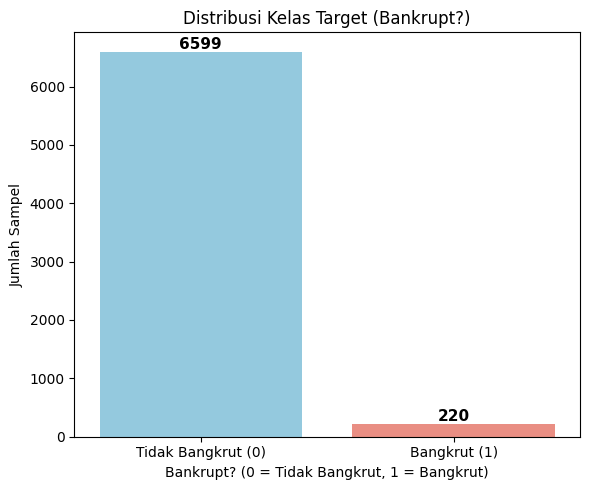

In [4]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.



# Lihat jumlah per kelas
print(df['Bankrupt?'].value_counts())
print(df['Bankrupt?'].value_counts(normalize=True) * 100)

# Bar plot distribusi kelas target
plt.figure(figsize=(6, 5))
ax = sns.countplot(data=df, x='Bankrupt?', palette=['skyblue', 'salmon'])

plt.title('Distribusi Kelas Target (Bankrupt?)')
plt.xlabel('Bankrupt? (0 = Tidak Bangkrut, 1 = Bangkrut)')
plt.ylabel('Jumlah Sampel')

# Tambahkan angka di atas bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks([0, 1], ['Tidak Bangkrut (0)', 'Bangkrut (1)'])
plt.tight_layout()
plt.show()

95


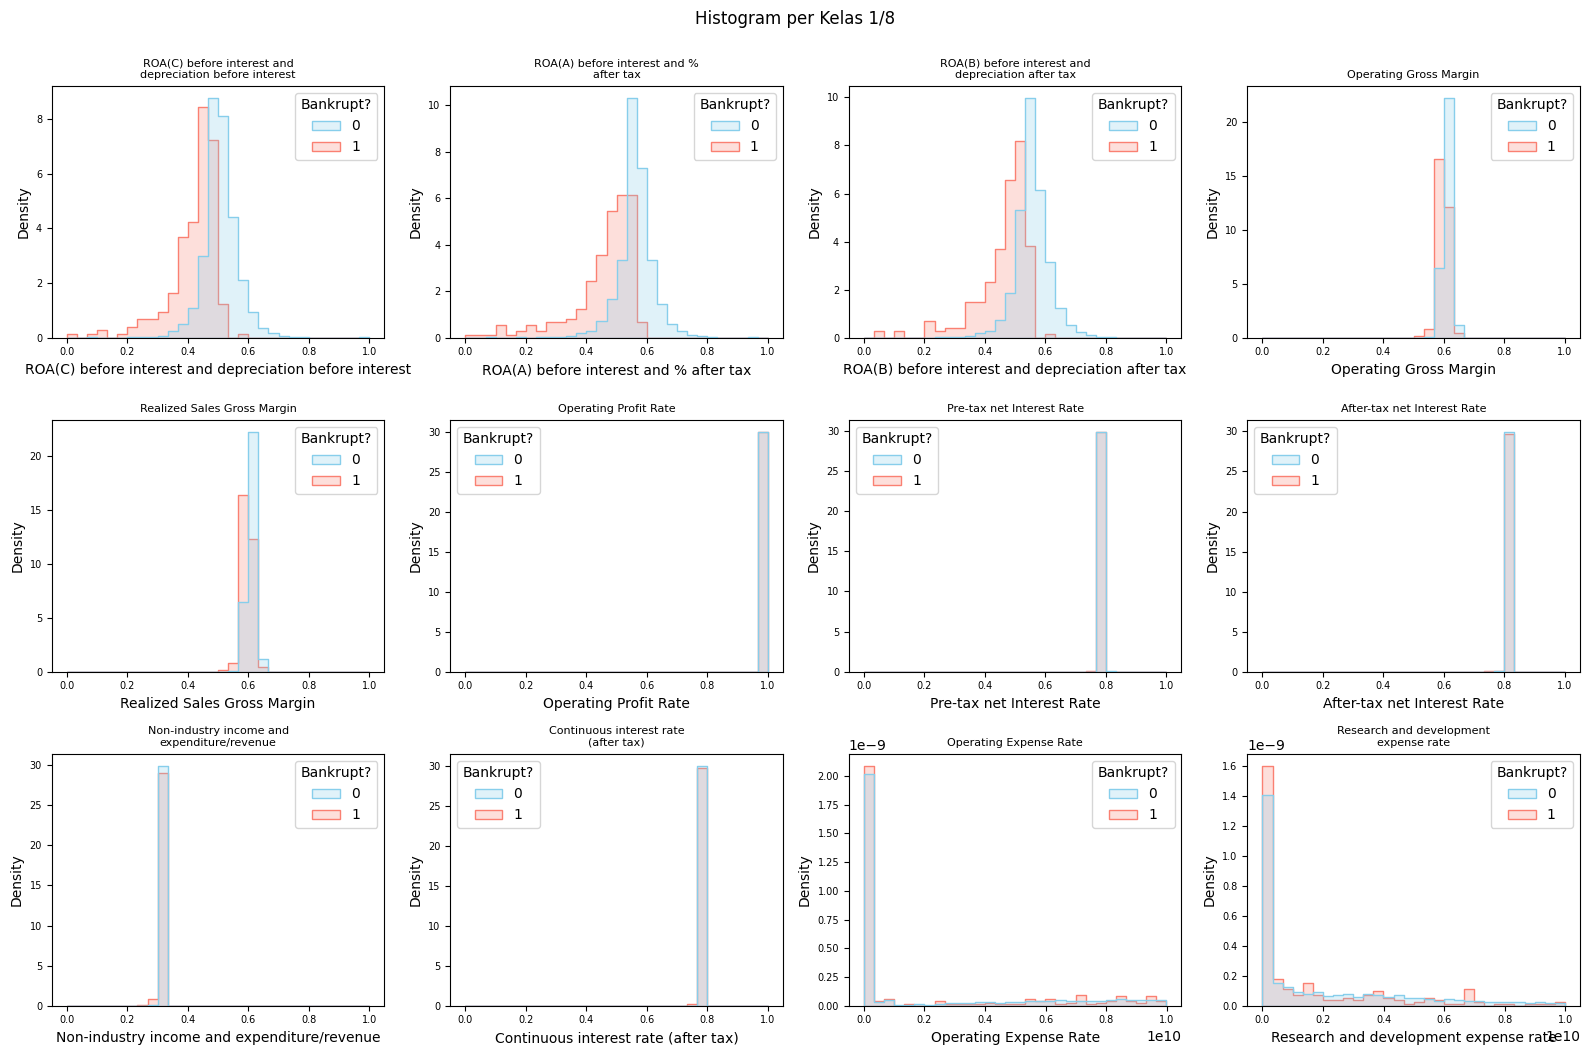

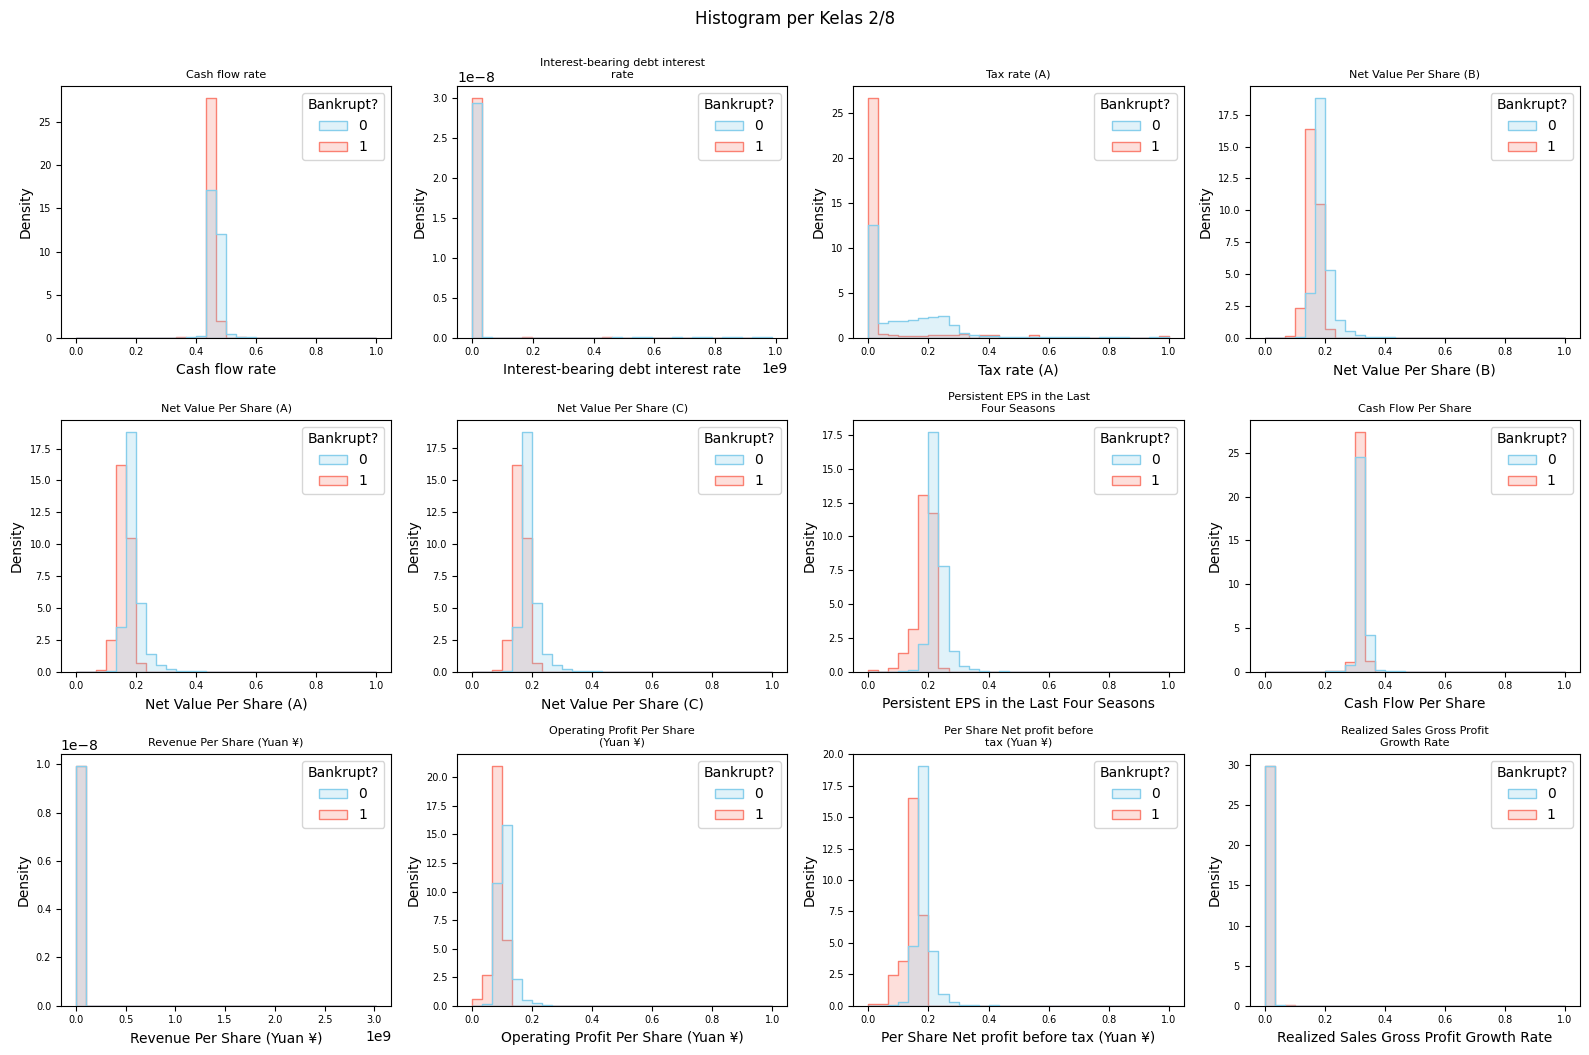

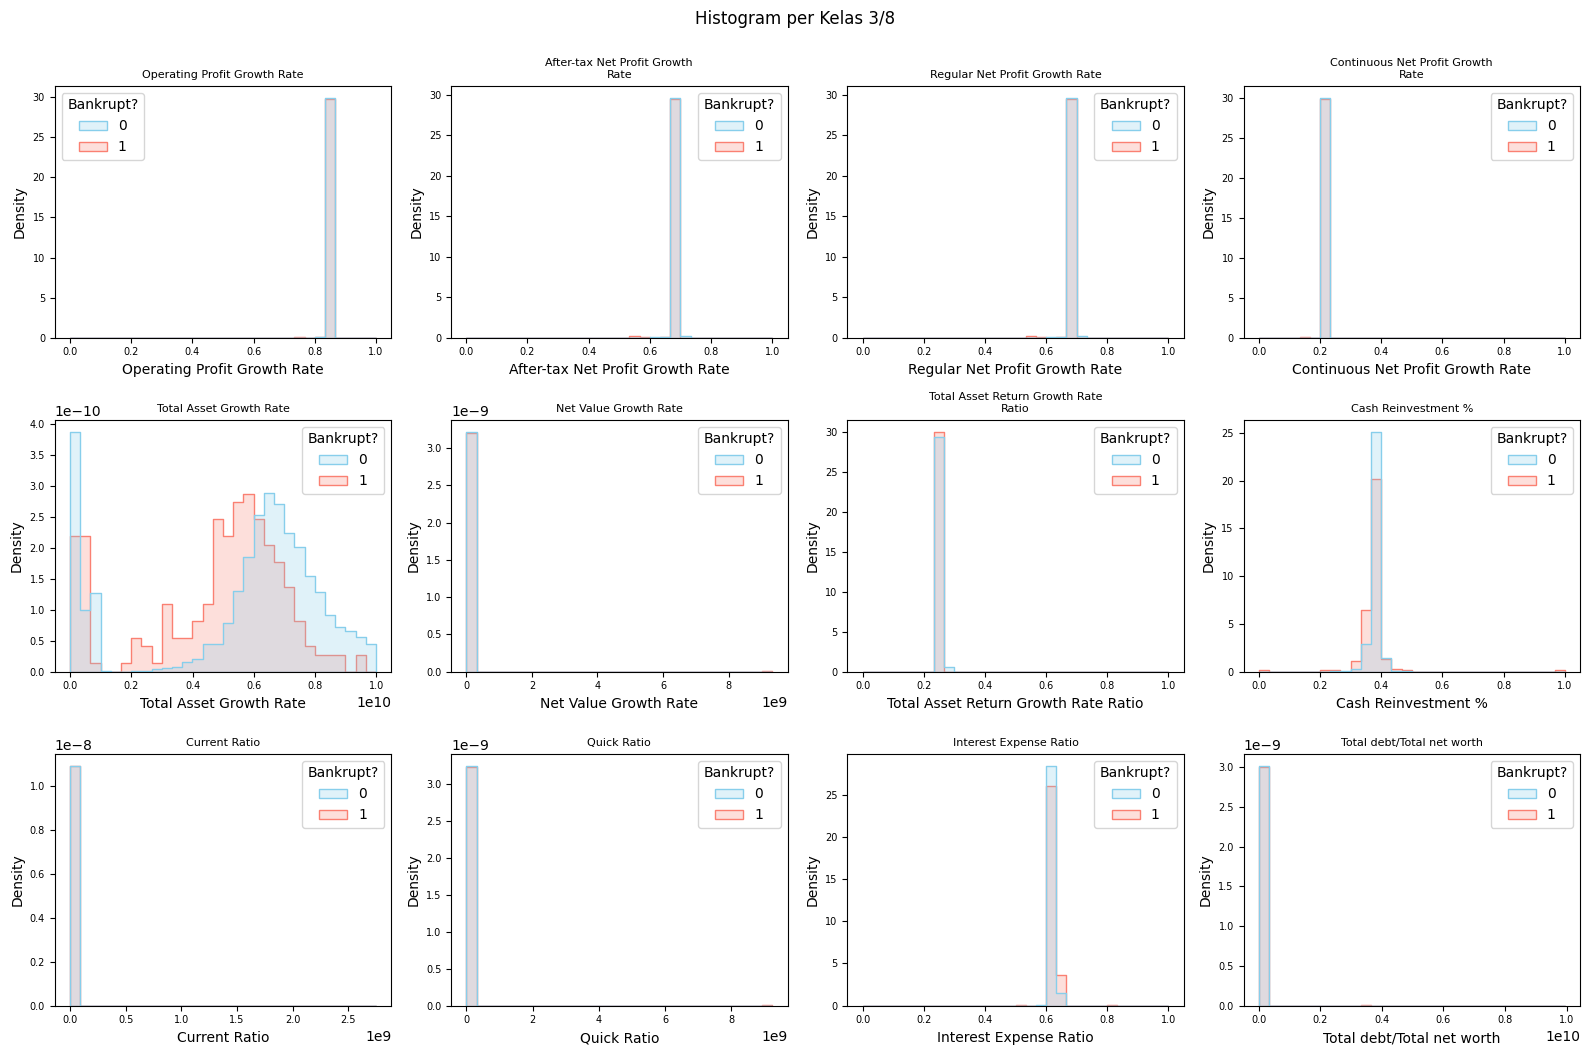

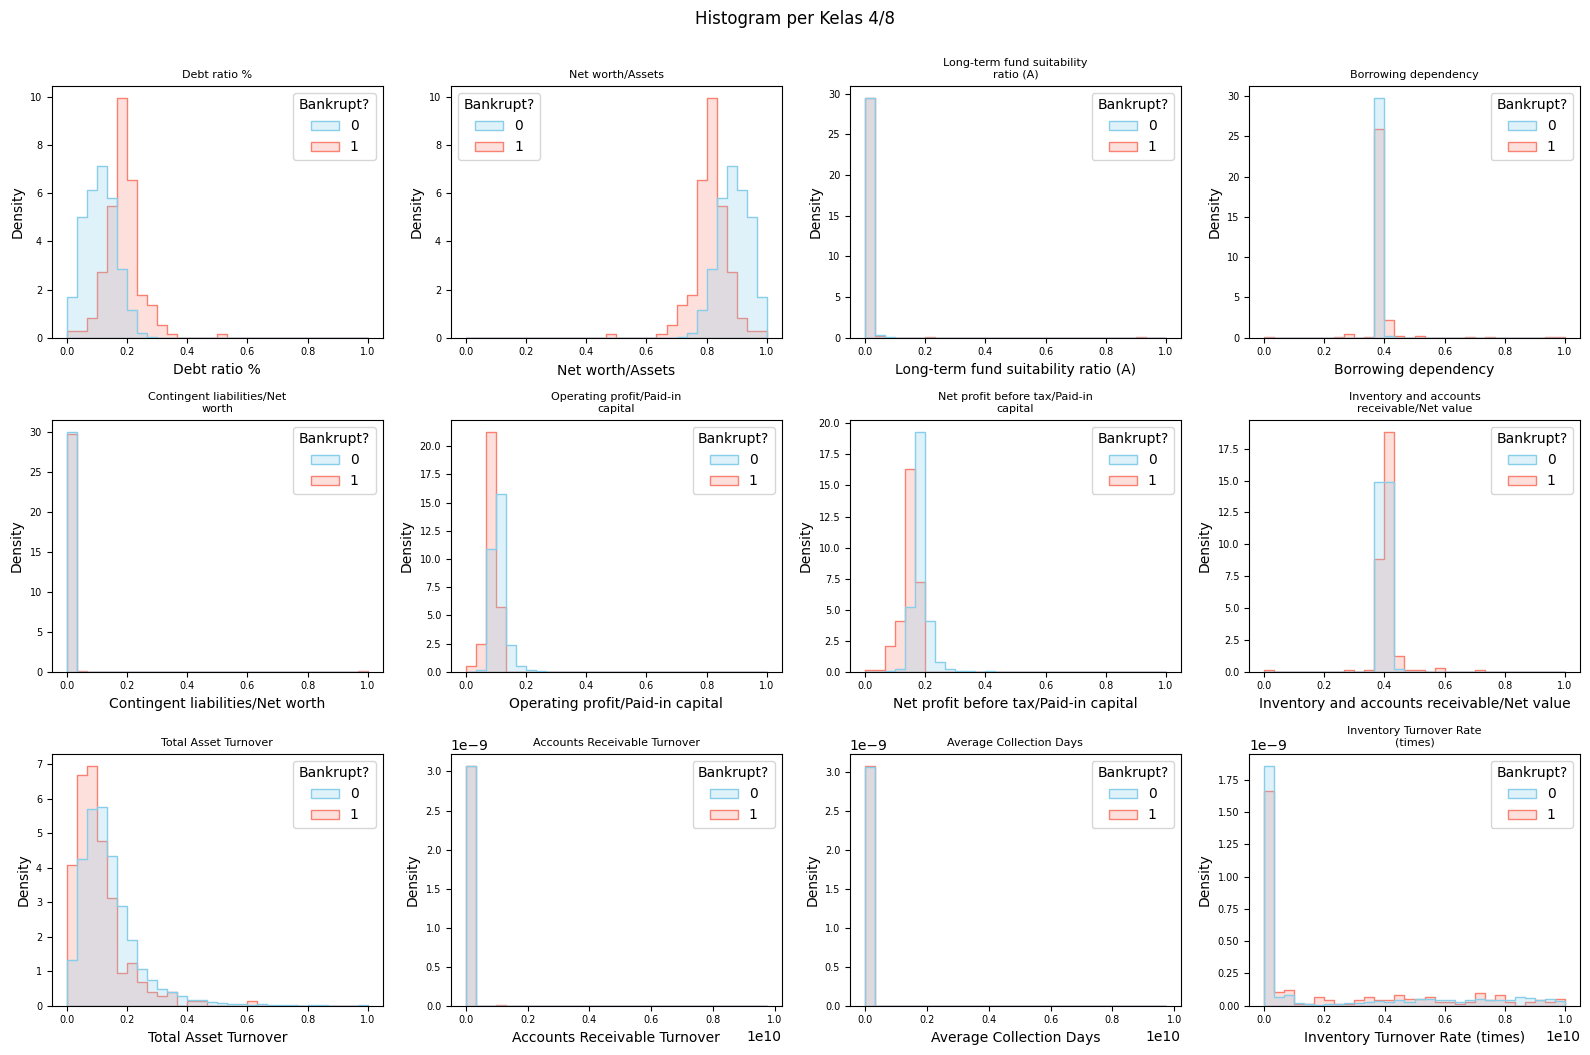

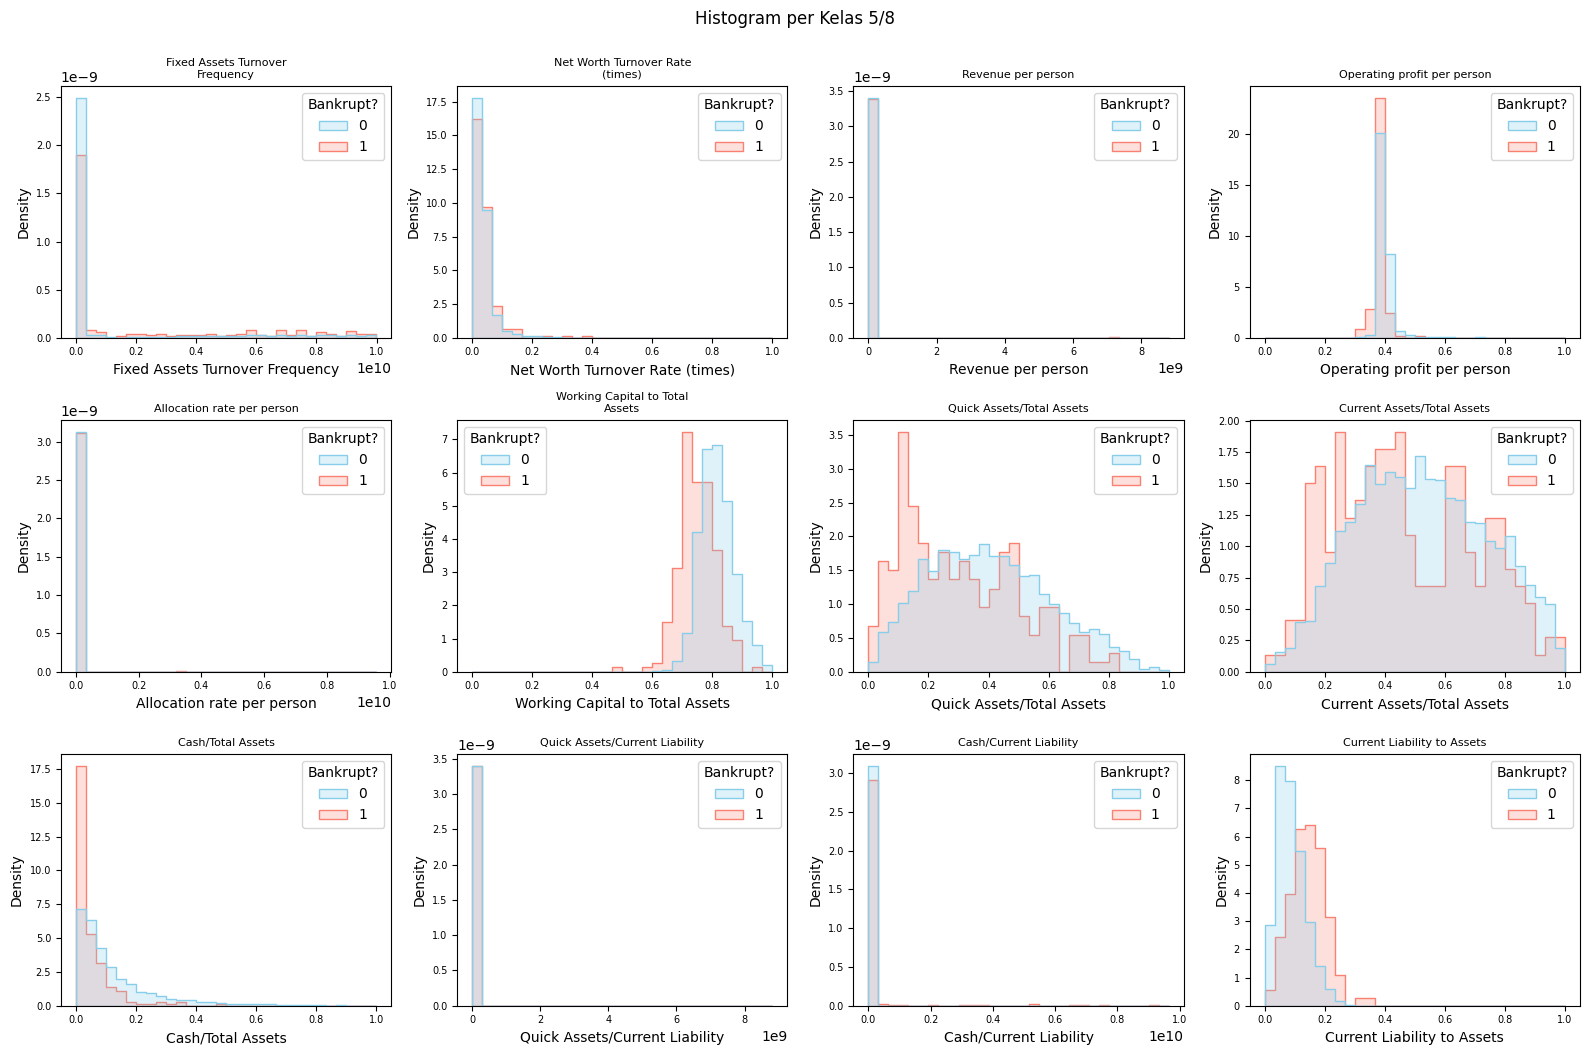

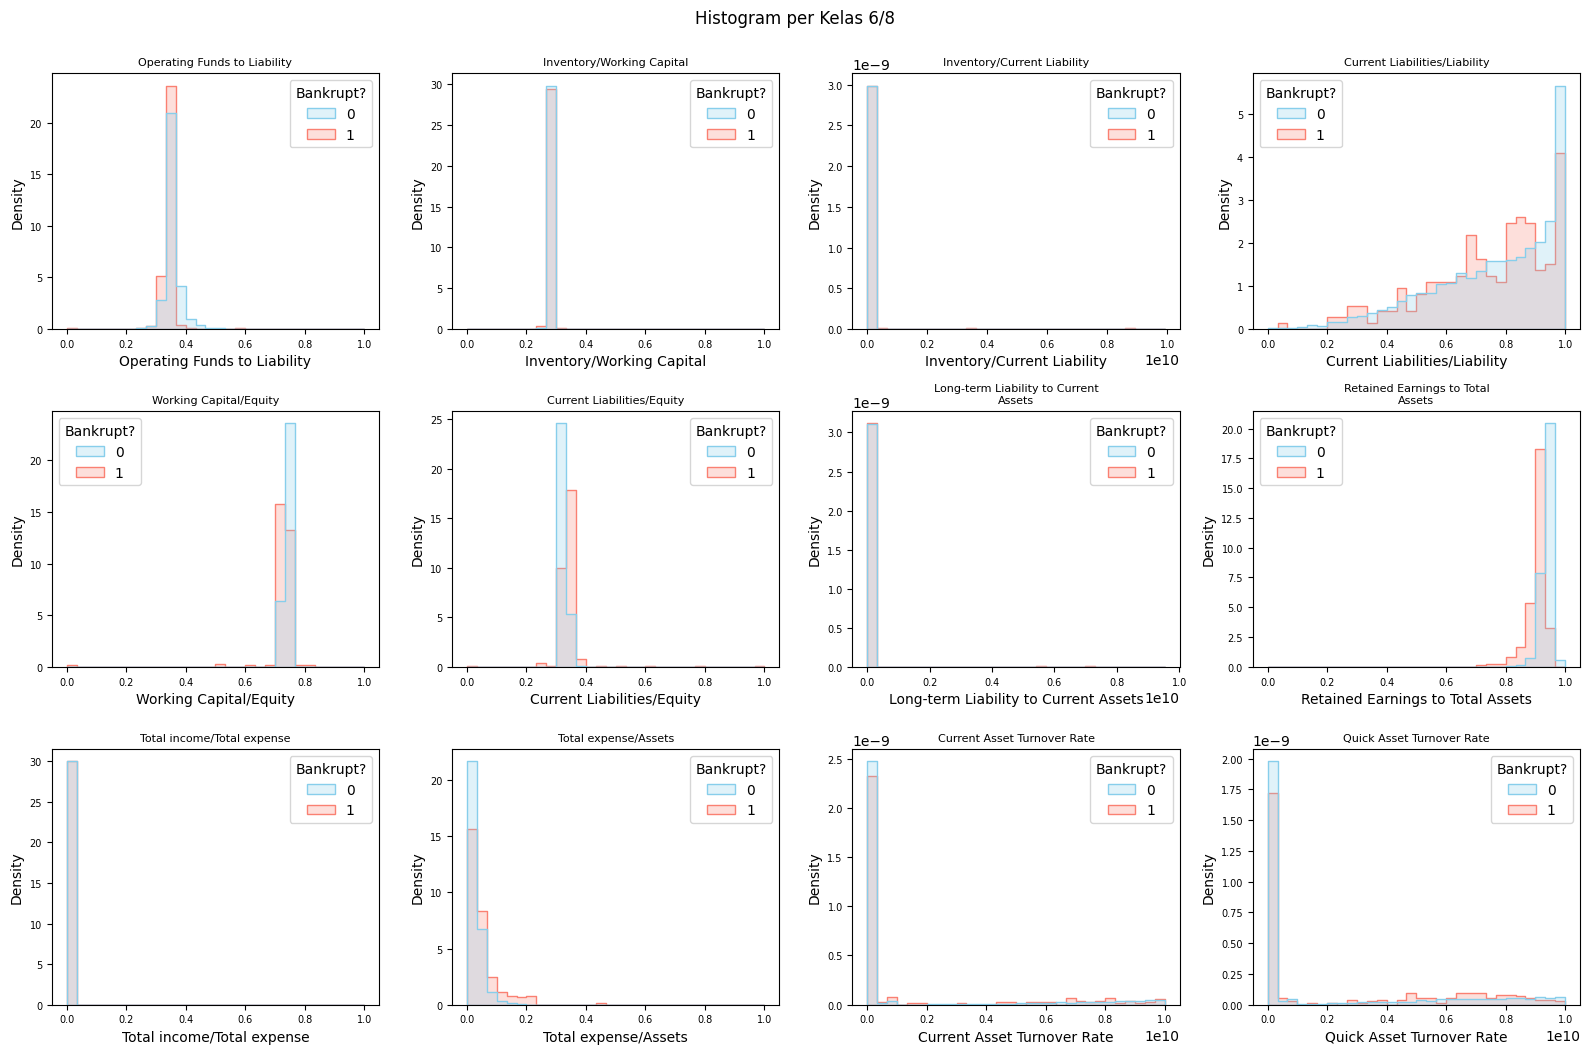

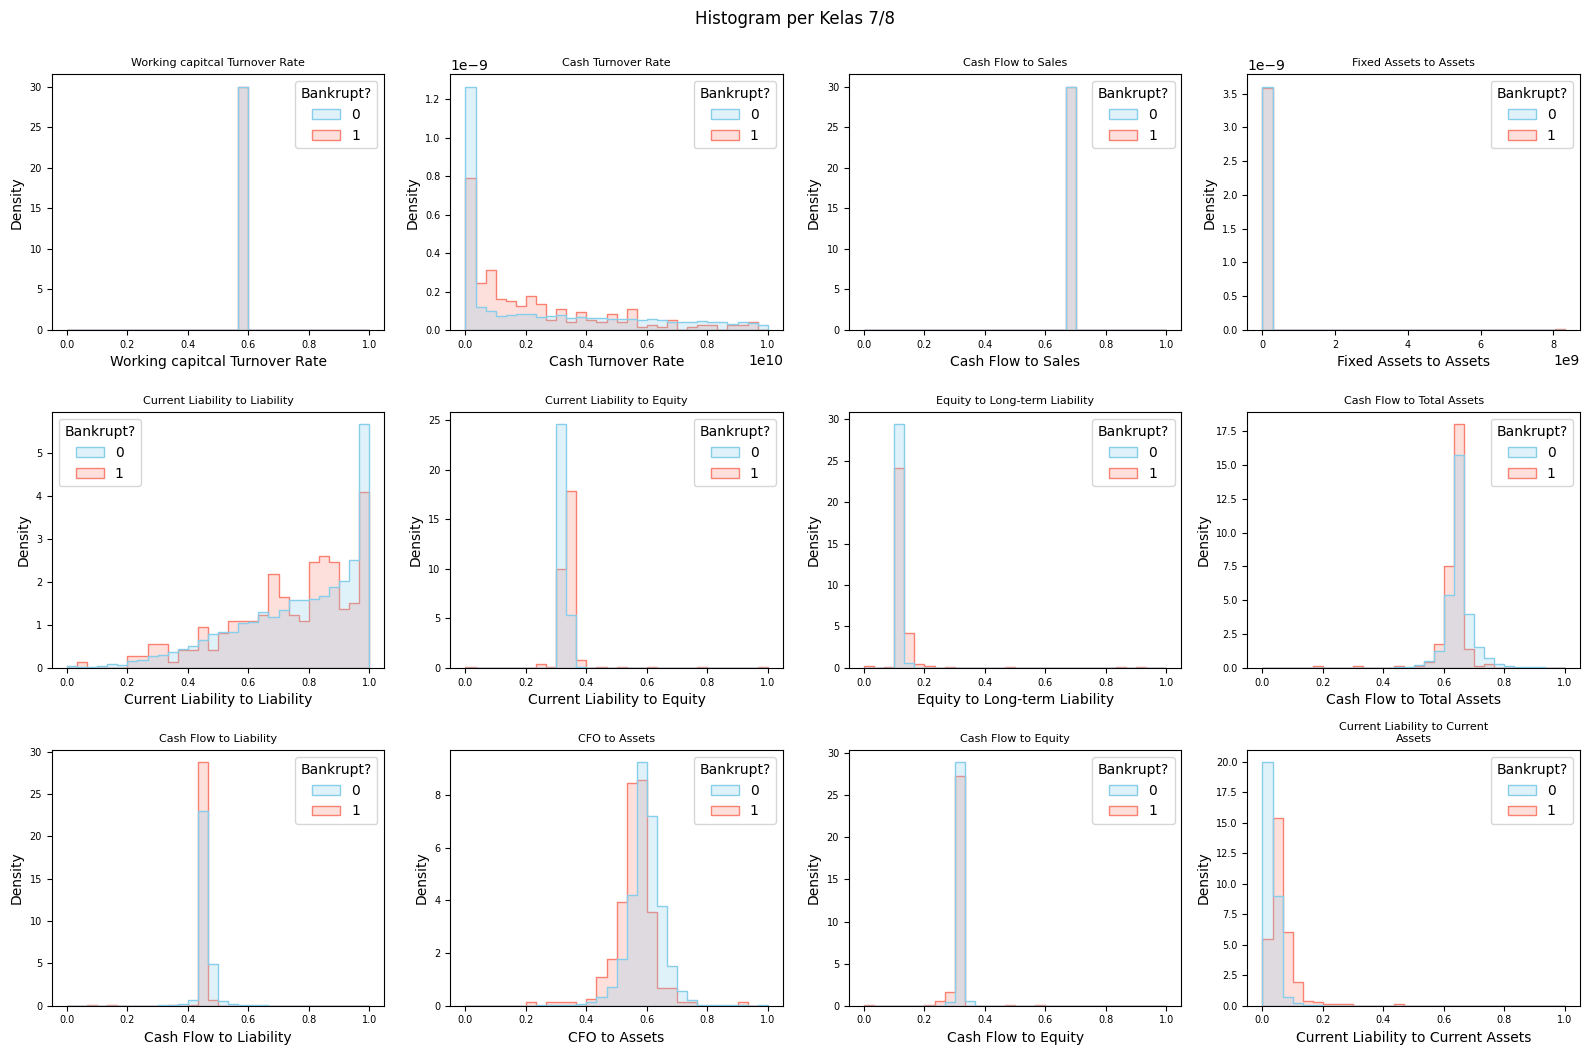

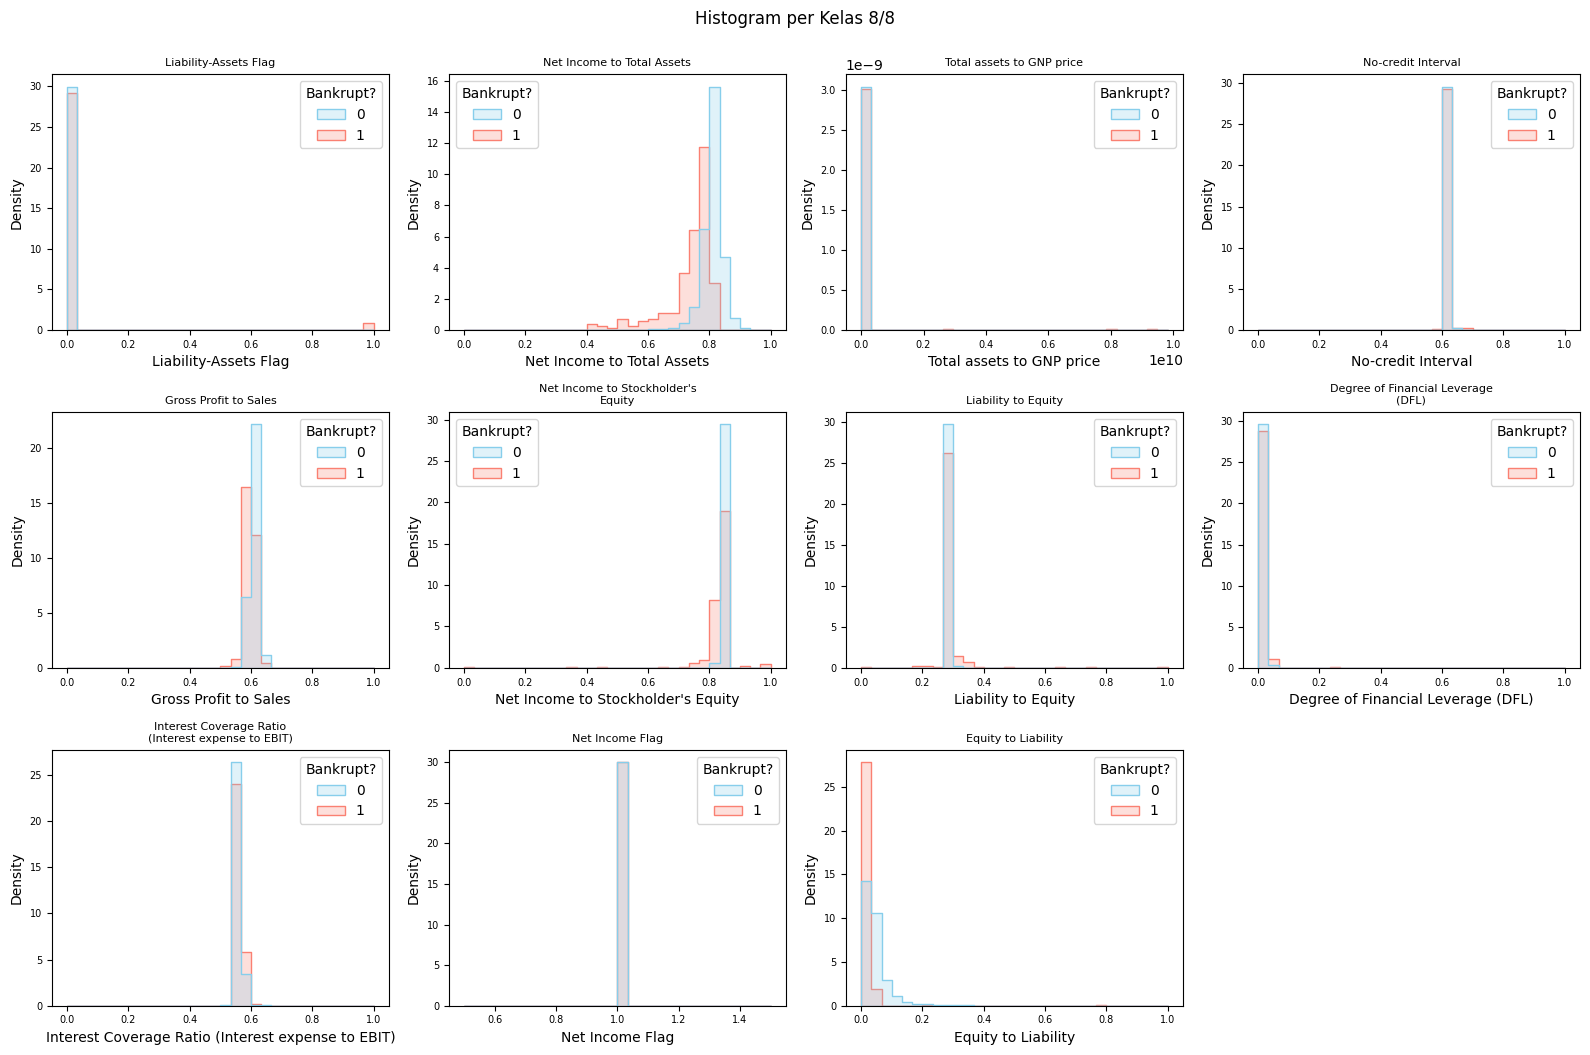

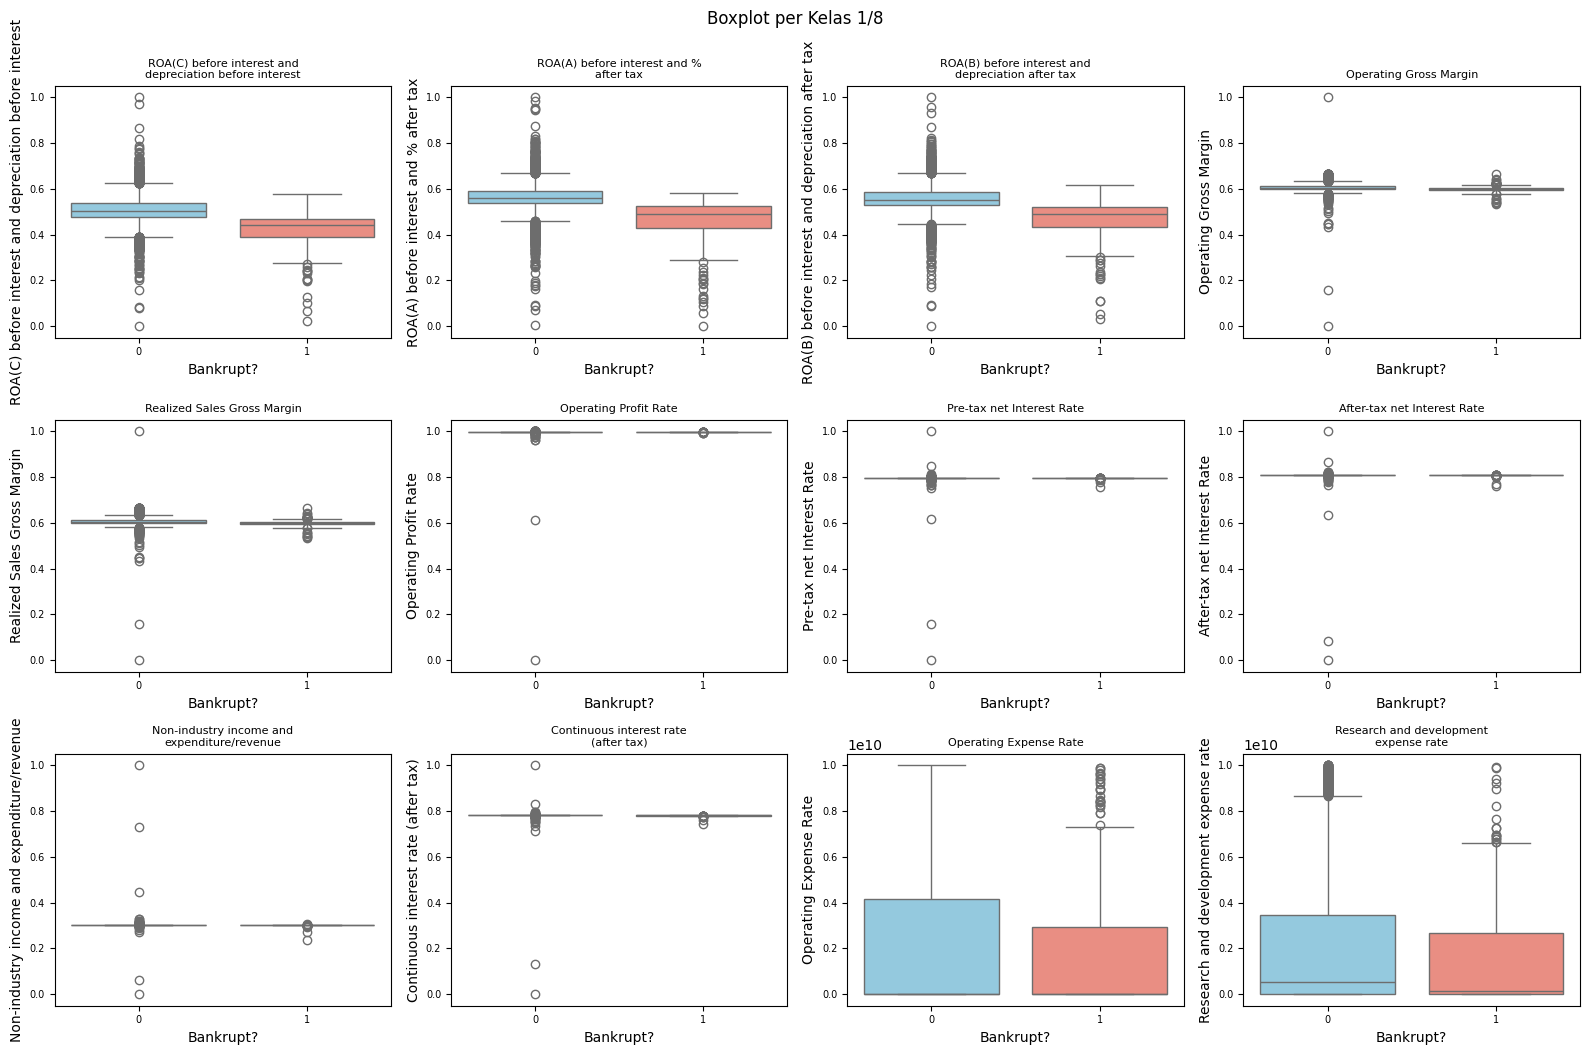

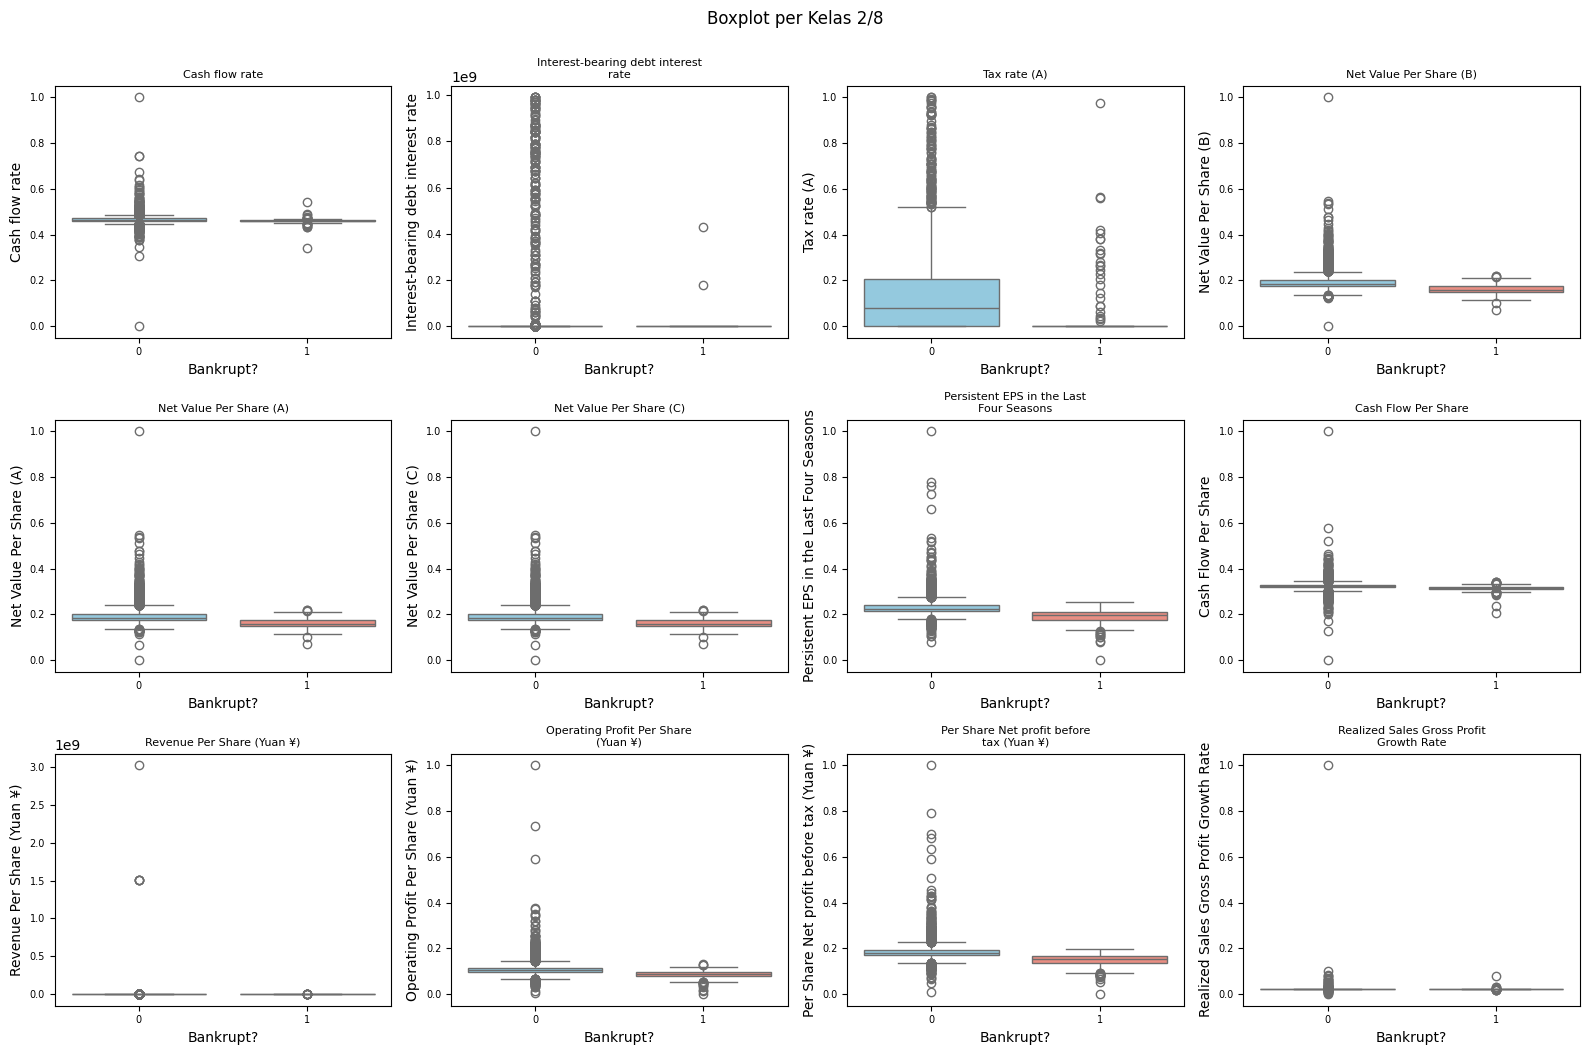

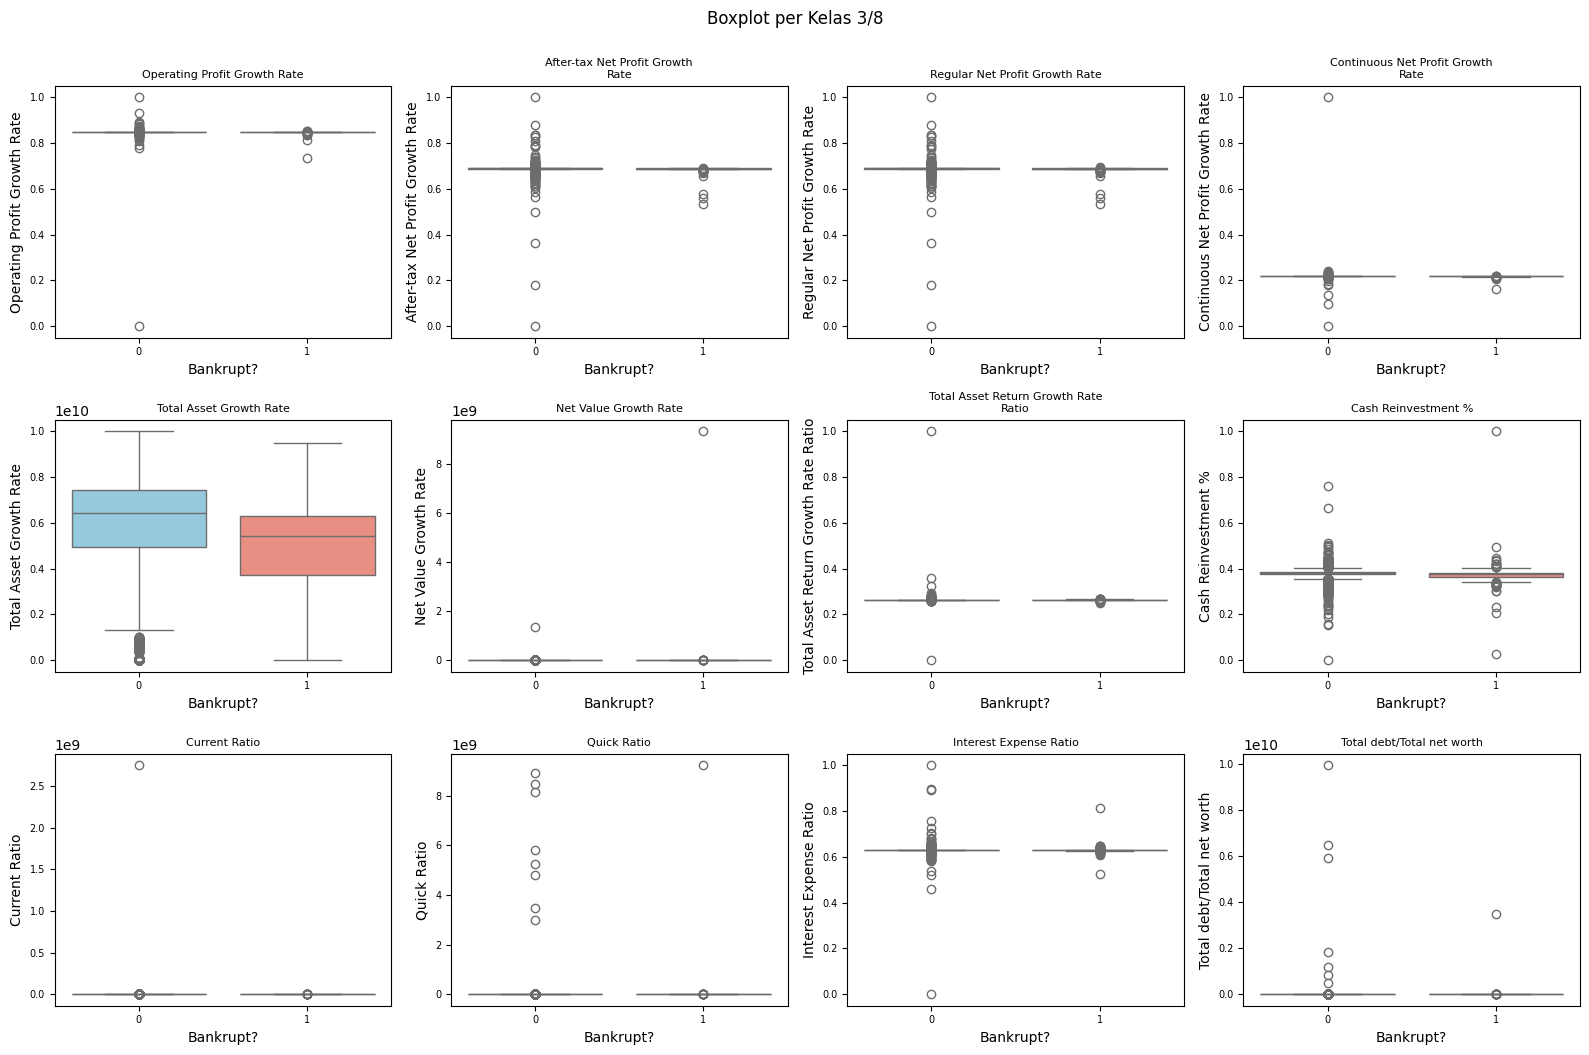

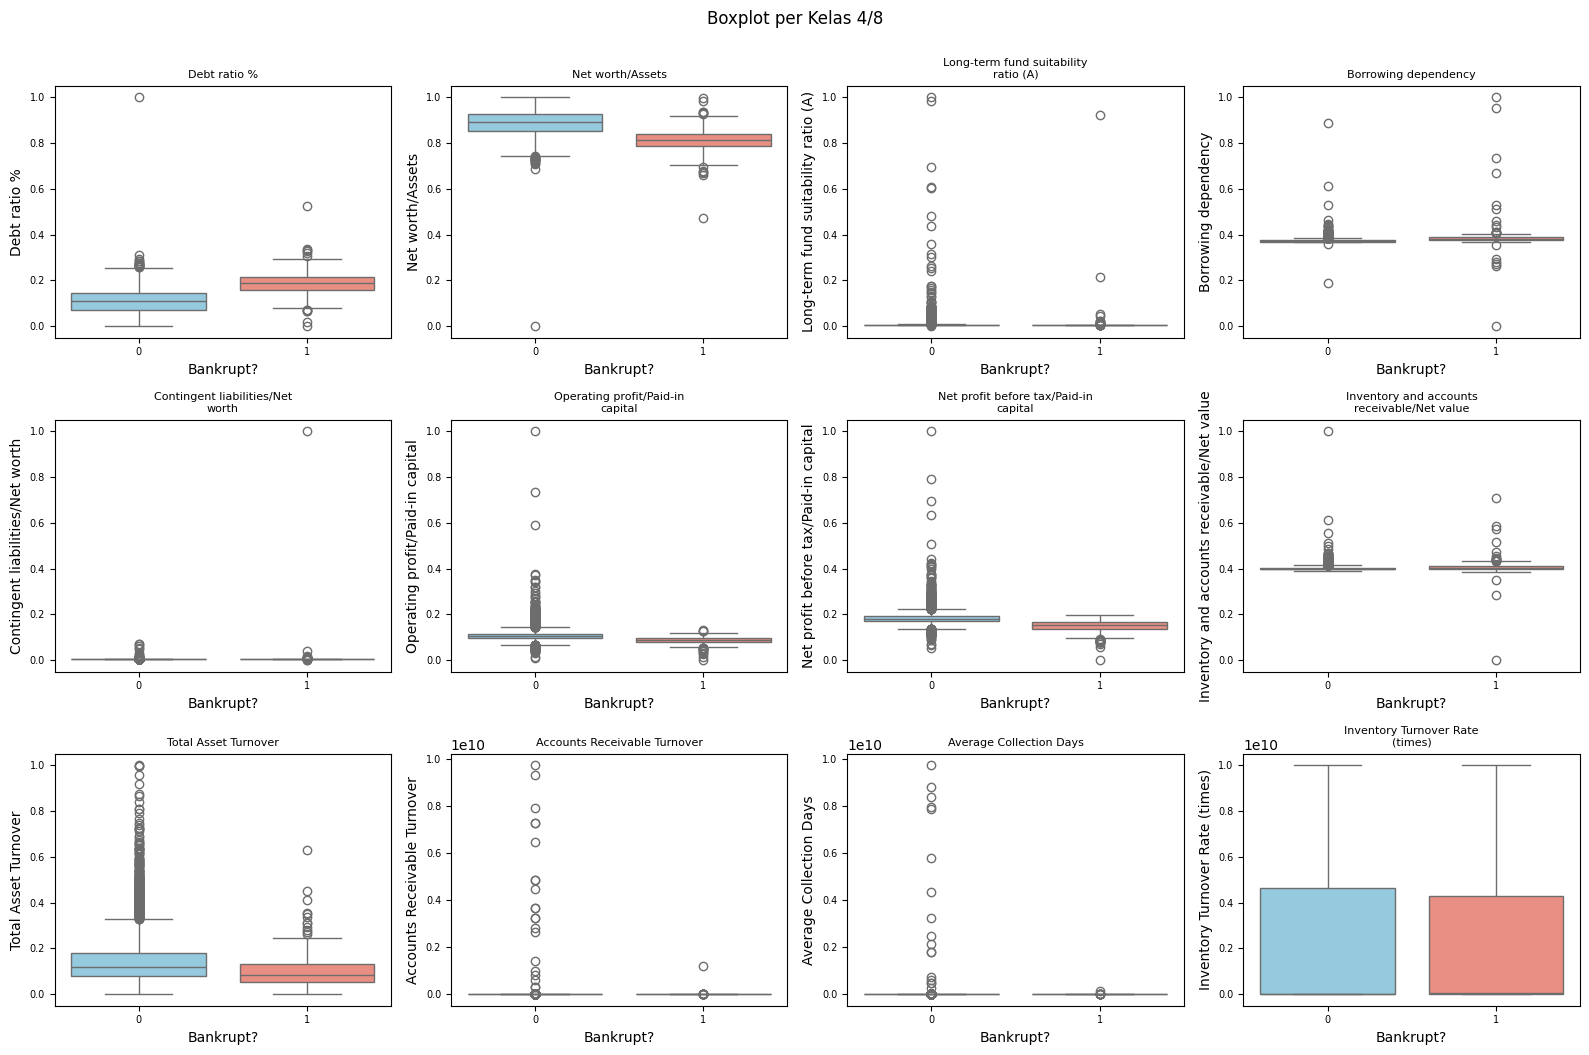

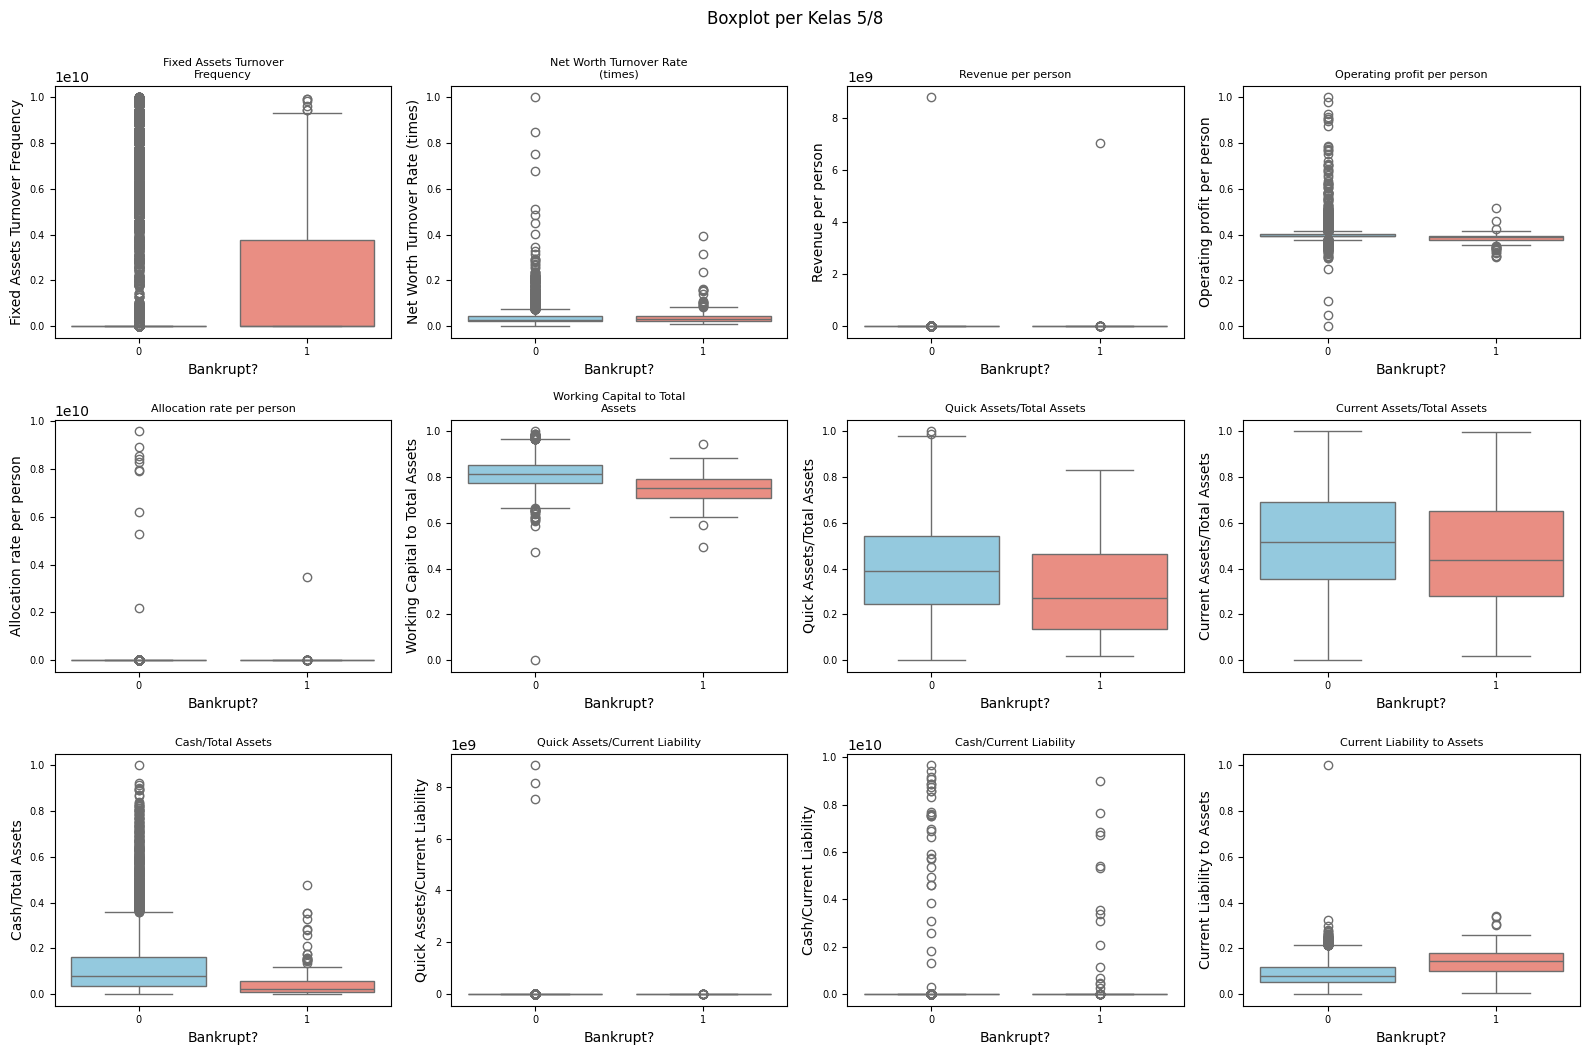

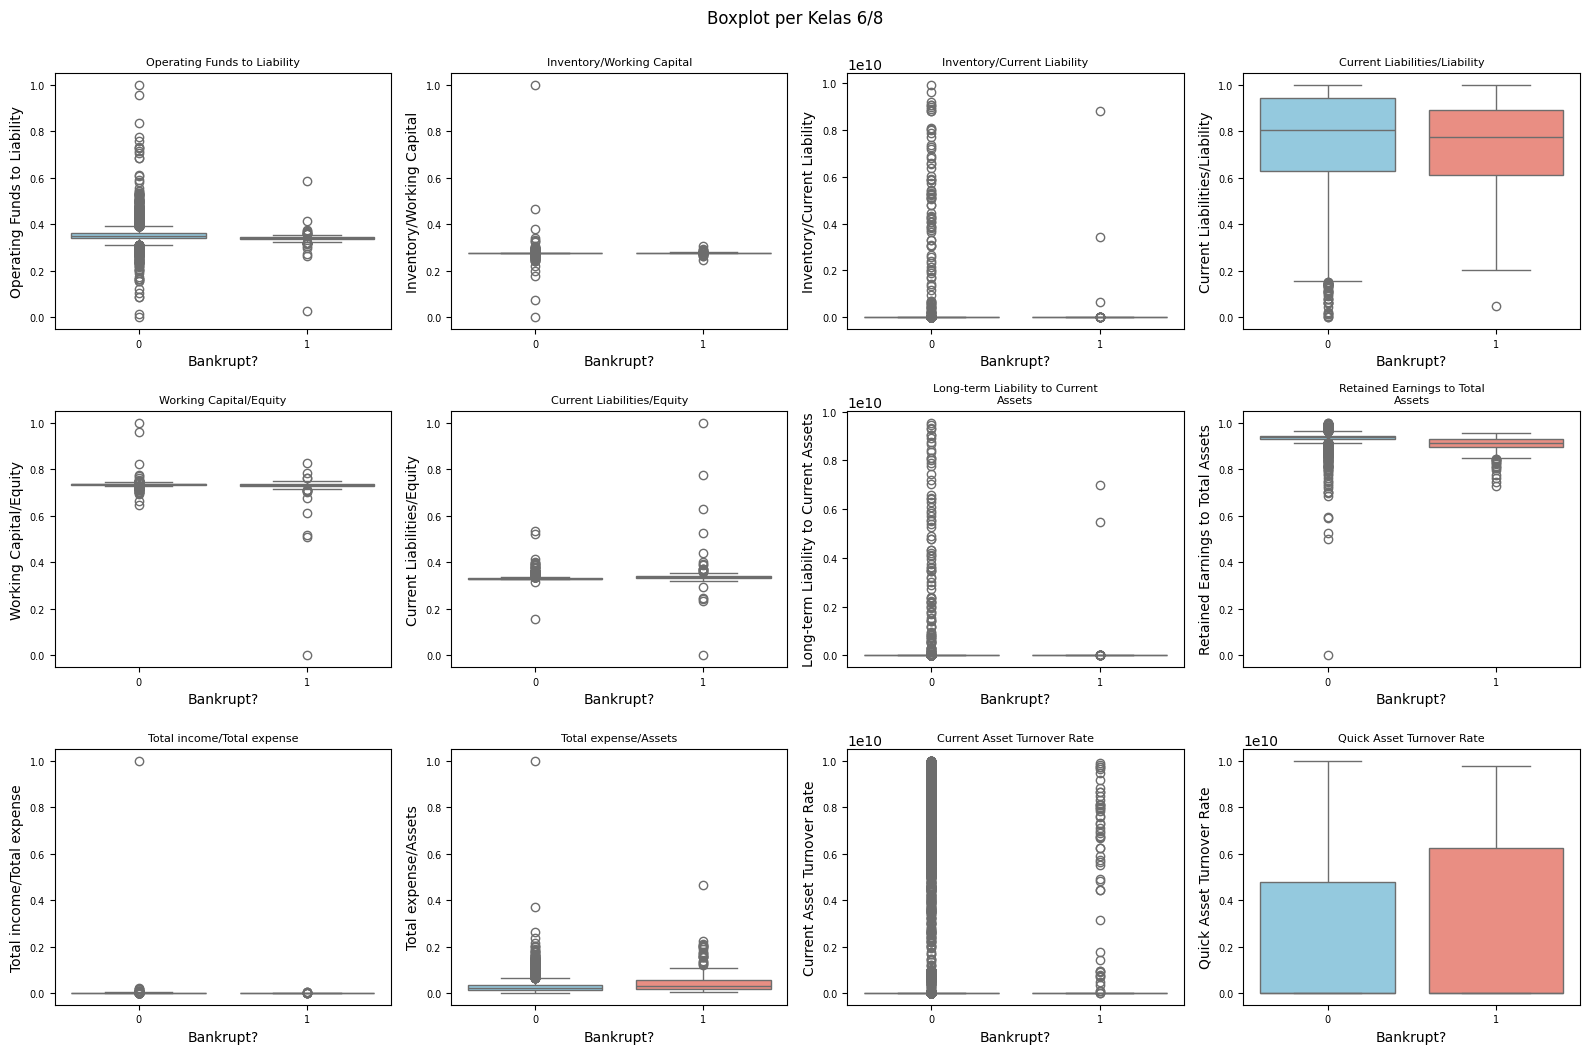

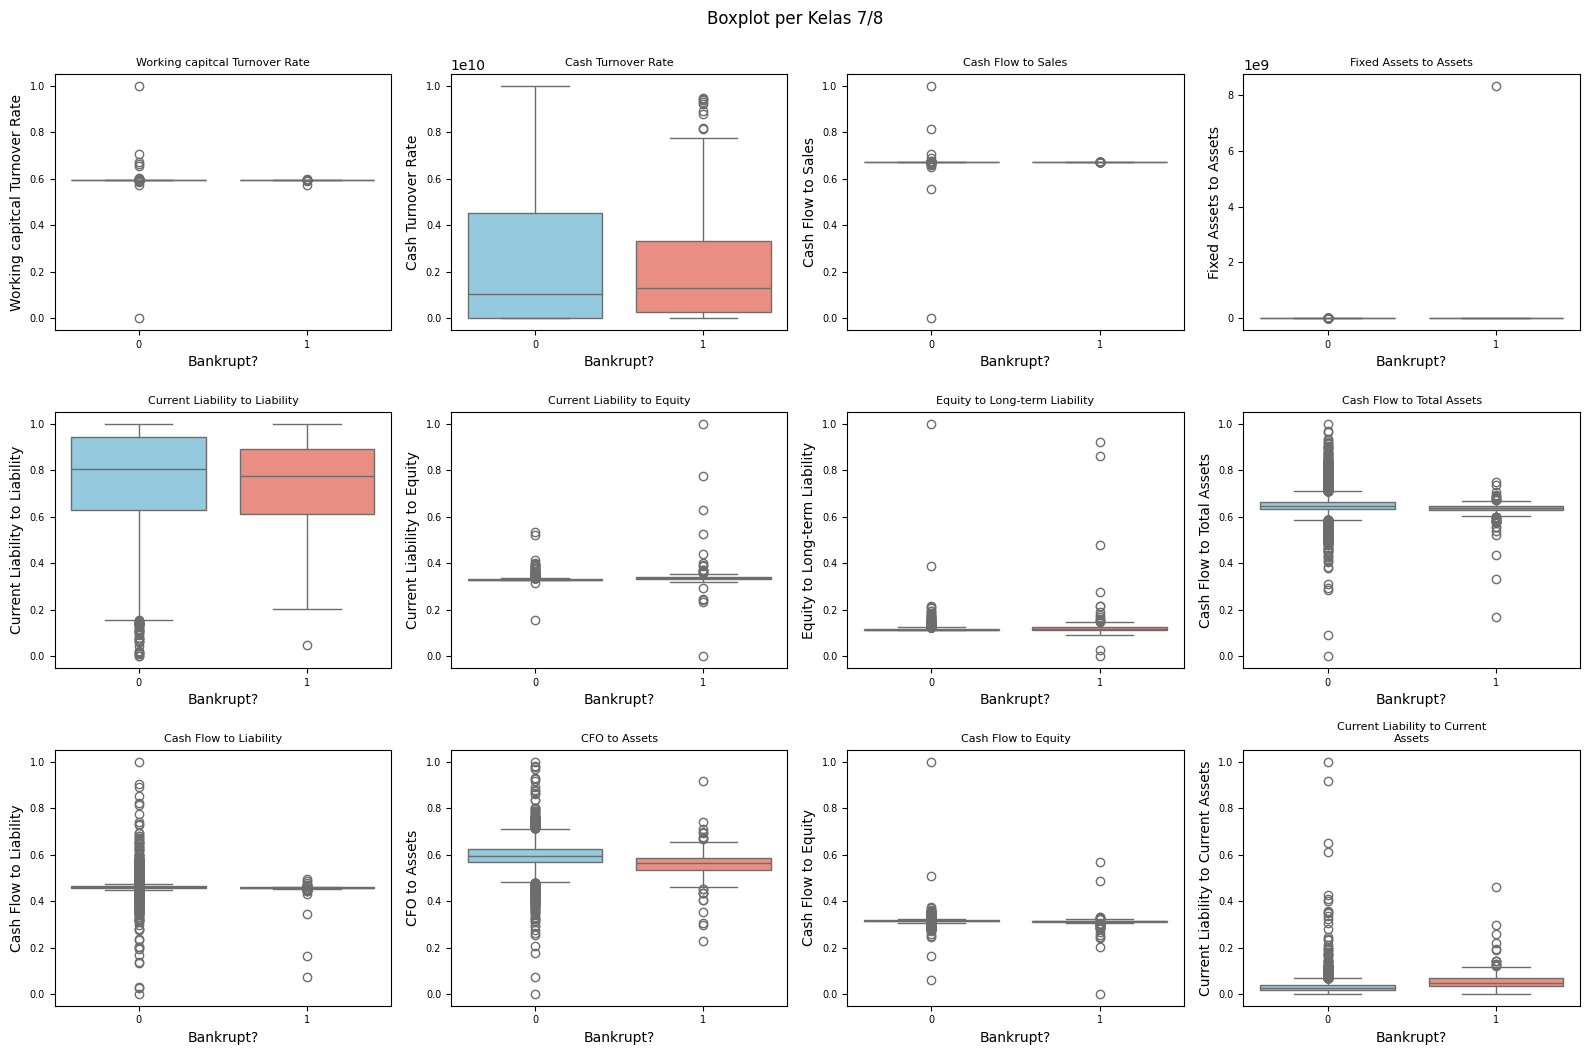

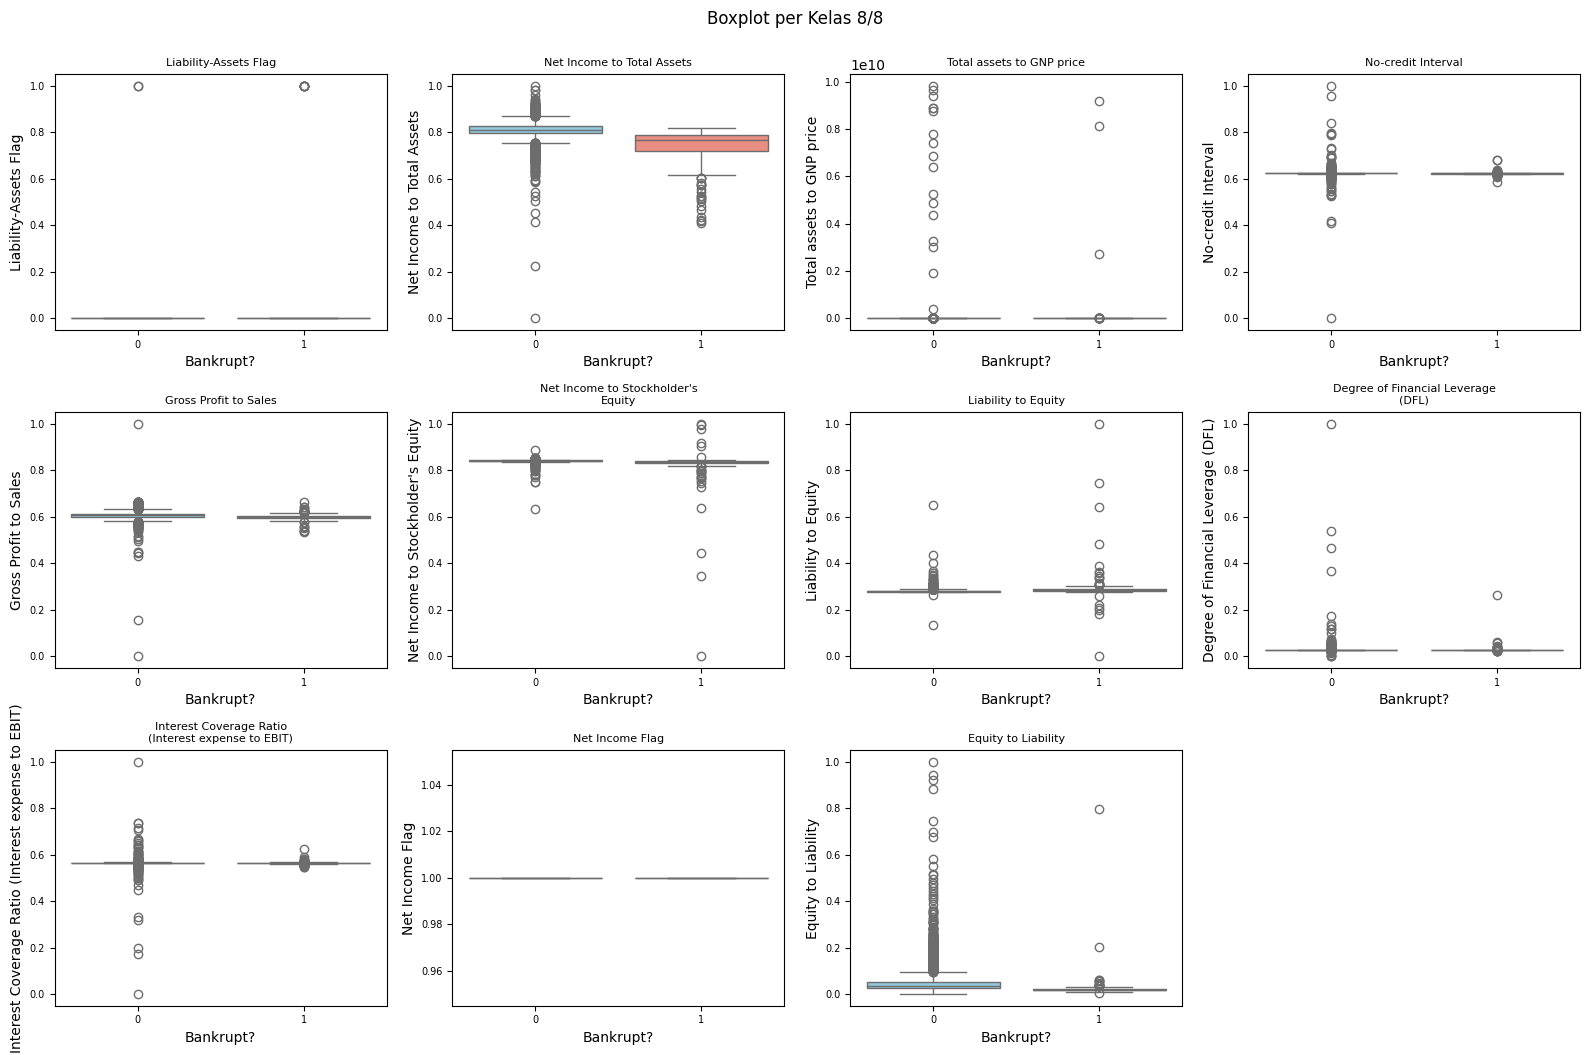

In [5]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas antar kelas.

df.columns = [c.strip() for c in df.columns]

target = 'Bankrupt?'
features = [c for c in df.columns if c != target]
print(len(features))

ncols, per_fig = 4, 12
nfig = math.ceil(len(features) / per_fig)

for f in range(nfig):
    batch = features[f*per_fig:(f+1)*per_fig]
    nrows = math.ceil(len(batch) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5*nrows))
    axes = axes.flatten()

    for ax, col in zip(axes, batch):
        sns.histplot(data=df, x=col, hue=target,
                     bins=30, kde=False, element='step',
                     stat='density', common_norm=False,
                     palette={0: 'skyblue', 1: 'salmon'}, ax=ax)
        ax.set_title(textwrap.fill(col, 30), fontsize=8)
        ax.tick_params(labelsize=7)

    for ax in axes[len(batch):]:
        fig.delaxes(ax)

    plt.suptitle(f'Histogram per Kelas {f+1}/{nfig}', y=1.0)
    plt.tight_layout()
    plt.show()

for f in range(nfig):
    batch = features[f*per_fig:(f+1)*per_fig]
    nrows = math.ceil(len(batch) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5*nrows))
    axes = axes.flatten()

    for ax, col in zip(axes, batch):
        sns.boxplot(data=df, x=target, y=col, hue=target,
                    palette={0: 'skyblue', 1: 'salmon'},
                    legend=False, ax=ax)
        ax.set_title(textwrap.fill(col, 30), fontsize=8)
        ax.tick_params(labelsize=7)

    for ax in axes[len(batch):]:
        fig.delaxes(ax)

    plt.suptitle(f'Boxplot per Kelas {f+1}/{nfig}', y=1.0)
    plt.tight_layout()
    plt.show()

def plot_fitur(col):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(data=df, x=col, hue=target, bins=30, kde=True,
                 element='step', stat='density', common_norm=False,
                 palette={0: 'skyblue', 1: 'salmon'}, ax=ax[0])
    ax[0].set_title(f'Histogram {col}')
    sns.boxplot(data=df, x=target, y=col, hue=target,
                palette={0: 'skyblue', 1: 'salmon'}, legend=False, ax=ax[1])
    ax[1].set_title(f'Boxplot {col}')
    plt.tight_layout()
    plt.show()


## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

Net Income to Total Assets                                 0.3155
ROA(A) before interest and % after tax                     0.2829
ROA(B) before interest and depreciation after tax          0.2731
ROA(C) before interest and depreciation before interest    0.2608
Net worth/Assets                                           0.2502
Debt ratio %                                               0.2502
Persistent EPS in the Last Four Seasons                    0.2196
Retained Earnings to Total Assets                          0.2178
Net profit before tax/Paid-in capital                      0.2079
Per Share Net profit before tax (Yuan ¥)                   0.2014
Name: Bankrupt?, dtype: float64


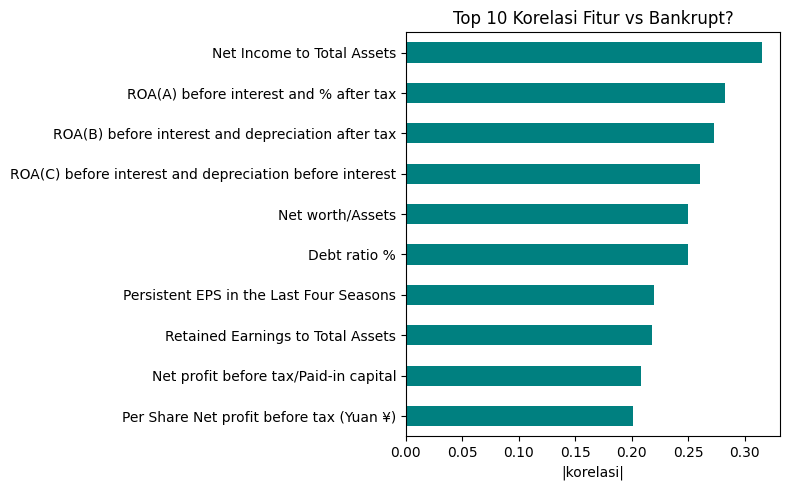

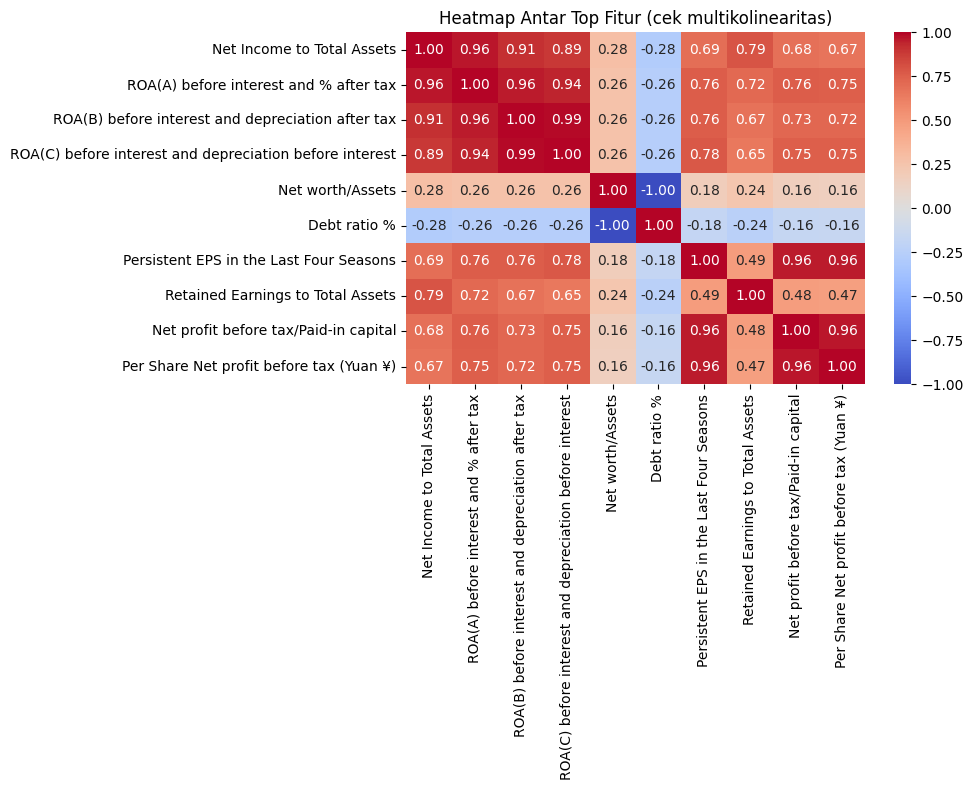

In [6]:
# 1. Korelasi (= point-biserial) semua fitur vs Bankrupt?
corr_target = df.corr(numeric_only=True)['Bankrupt?'].drop('Bankrupt?', errors='ignore')
corr_target = corr_target.dropna() # buang 'Net Income Flag' (konstan, isi 1 semua)
top10 = corr_target.abs().sort_values(ascending=False).head(10)
print(top10.round(4))

# 2. Barplot korelasi vs target
plt.figure(figsize=(8,5))
top10.sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Korelasi Fitur vs Bankrupt?')
plt.xlabel('|korelasi|')
plt.tight_layout(); plt.show()

# 3. Heatmap antar top fitur (cek redundansi)
plt.figure(figsize=(10,8))
sns.heatmap(df[top10.index].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap Antar Top Fitur (cek multikolinearitas)')
plt.tight_layout(); plt.show()

# 2. Preprocessing

In [7]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

In [21]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Catatan: Decision Tree secara konsep bisa menangani fitur kategorikal secara langsung tanpa One-Hot Encoding,
# tetapi implementasi DecisionTreeClassifier pada scikit-learn tetap mengharuskan input berupa angka.

from sklearn.preprocessing import OrdinalEncoder

# 1. Cek kolom kategorikal
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
print('Kolom kategorikal:', cat_cols)

if len(cat_cols) == 0:
    print('Tidak ada kategorikal -> skip encoding. Flag (0/1) sudah numerik.')
    df_encoded = df.copy()
else:
    # Untuk Tree: Ordinal/Label lebih cocok dari One-Hot
    # (One-Hot bikin split fragmented & pohon makin dalam)
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    df_encoded = df.copy()
    df_encoded[cat_cols] = enc.fit_transform(df[cat_cols])

Kolom kategorikal: []
Tidak ada kategorikal -> skip encoding. Flag (0/1) sudah numerik.


In [22]:
# Drop otomatis salah satu dari pasangan yang korelasinya > 0.85
top10 = corr_target.abs().sort_values(ascending=False).head(10).index.tolist()

to_drop = set()
for i in range(len(top10)):
    for j in range(i+1, len(top10)):
        f1, f2 = top10[i], top10[j]
        if abs(df[f1].corr(df[f2])) > 0.85:
            # buang yang korelasi ke target lebih kecil
            drop = f2 if abs(corr_target[f1]) >= abs(corr_target[f2]) else f1
            to_drop.add(drop)

selected_features = [f for f in top10 if f not in to_drop]
print('Buang:', to_drop)
print('Dipakai:', selected_features)

Buang: {'ROA(B) before interest and depreciation after tax', 'ROA(A) before interest and % after tax', 'ROA(C) before interest and depreciation before interest', 'Debt ratio %', 'Net profit before tax/Paid-in capital', 'Per Share Net profit before tax (Yuan ¥)'}
Dipakai: ['Net Income to Total Assets', 'Net worth/Assets', 'Persistent EPS in the Last Four Seasons', 'Retained Earnings to Total Assets']


In [23]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

from sklearn.model_selection import train_test_split

# Pisahkan fitur (X) dan target (y) — pakai fitur non-redundan hasil EDA
X = df[selected_features]
y = df['Bankrupt?'].astype(int)

# Bagi 80:20 + stratify (wajib karena imbalance ~96.8% vs 3.2%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('X_train:', X_train.shape, 'X_test:', X_test.shape)
print('\nDistribusi train (%):\n', (y_train.value_counts(normalize=True)*100).round(2))
print('\nDistribusi test (%):\n', (y_test.value_counts(normalize=True)*100).round(2))

X_train: (5455, 4) X_test: (1364, 4)

Distribusi train (%):
 Bankrupt?
0    96.77
1     3.23
Name: proportion, dtype: float64

Distribusi test (%):
 Bankrupt?
0    96.77
1     3.23
Name: proportion, dtype: float64


**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [25]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='gini' menggunakan train set.

from sklearn.tree import DecisionTreeClassifier

# Baseline Gini (belum regularisasi -> max_depth=None)
clf_gini = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

clf_gini.fit(X_train, y_train)

print('Depth:', clf_gini.get_depth())
print('Leaves:', clf_gini.get_n_leaves())

Depth: 23
Leaves: 200


In [26]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

# Prediksi label pada test set
y_pred_gini = clf_gini.predict(X_test)

# (opsional, untuk ROC-AUC nanti)
y_proba_gini = clf_gini.predict_proba(X_test)[:, 1]

## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [27]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='entropy' menggunakan train set.
# Gunakan nilai hyperparameter lain yang sama seperti model Gini di atas, agar perbandingan adil.

# Sama persis seperti Gini, beda criterion saja biar adil
clf_entropy = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

clf_entropy.fit(X_train, y_train)

print('Depth:', clf_entropy.get_depth())
print('Leaves:', clf_entropy.get_n_leaves())

Depth: 20
Leaves: 185


In [28]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

# Prediksi label model Entropy pada test set
y_pred_entropy = clf_entropy.predict(X_test)

# (opsional, untuk ROC-AUC nanti)
y_proba_entropy = clf_entropy.predict_proba(X_test)[:, 1]

## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [29]:
# Latih beberapa model DecisionTreeClassifier dengan variasi nilai max_depth,
# misalnya 1, 2, 3, 5, 10, dan None (tanpa batas kedalaman).
# Gunakan kriteria split terbaik dari salah satu percobaan sebelumnya (Gini atau Entropy).

depths = [1, 2, 3, 5, 10, None]
# Ganti ke 'entropy' kalau di evaluasi sebelumnya entropy menang
BEST_CRITERION = 'gini'

models_depth = {}
for d in depths:
    clf = DecisionTreeClassifier(
        criterion=BEST_CRITERION,
        max_depth=d,
        random_state=42
    )
    clf.fit(X_train, y_train)
    models_depth[d] = clf
    print(f"max_depth={str(d):>4} | depth aktual={clf.get_depth():>2} | leaves={clf.get_n_leaves():>3}")

max_depth=   1 | depth aktual= 1 | leaves=  2
max_depth=   2 | depth aktual= 2 | leaves=  4
max_depth=   3 | depth aktual= 3 | leaves=  8
max_depth=   5 | depth aktual= 5 | leaves= 25
max_depth=  10 | depth aktual=10 | leaves=110
max_depth=None | depth aktual=23 | leaves=200


In [30]:
# Hitung akurasi pada train set dan test set untuk setiap nilai max_depth yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.

from sklearn.metrics import accuracy_score

train_acc, test_acc = [], []

for d in depths:
    clf = models_depth[d]
    train_acc.append(accuracy_score(y_train, clf.predict(X_train)))
    test_acc.append(accuracy_score(y_test, clf.predict(X_test)))

# Simpan rapi buat plotting
import pandas as pd
depth_labels = [str(d) for d in depths]  # 'None' biar gampang diplot
df_depth = pd.DataFrame({
    'max_depth': depth_labels,
    'train_acc': train_acc,
    'test_acc': test_acc
})
display(df_depth.round(4))

,max_depth,train_acc,test_acc
0,1,0.9677,0.9677
1,2,0.9701,0.9677
2,3,0.9701,0.9677
3,5,0.9747,0.9677
4,10,0.9877,0.9670
5,None,1.0000,0.9597


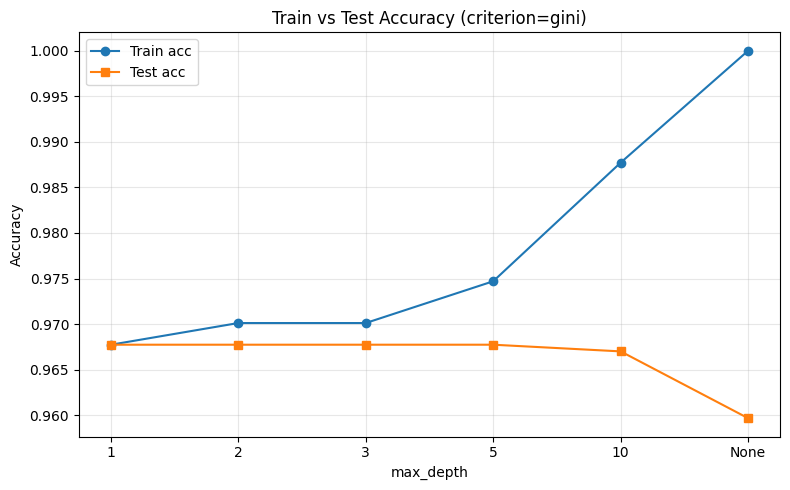

In [31]:
# Plot grafik akurasi training vs testing terhadap max_depth dalam satu chart.
# Amati pada titik berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).

import matplotlib.pyplot as plt

x = range(len(depths))
plt.figure(figsize=(8,5))
plt.plot(x, train_acc, marker='o', label='Train acc')
plt.plot(x, test_acc, marker='s', label='Test acc')
plt.xticks(x, [str(d) for d in depths])
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title(f'Train vs Test Accuracy (criterion={BEST_CRITERION})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [32]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model Gini dan Entropy.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def calc_metrics(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, zero_division=0),
        recall_score(y_true, y_pred, zero_division=0),
        f1_score(y_true, y_pred, zero_division=0)
    ]

results = pd.DataFrame(
    [calc_metrics(y_test, y_pred_gini), calc_metrics(y_test, y_pred_entropy)],
    index=['Gini', 'Entropy'],
    columns=['Accuracy', 'Precision', 'Recall', 'F1-Score']
)
display(results.round(4))

,Accuracy,Precision,Recall,F1-Score
Gini,0.9597,0.3590,0.3182,0.3373
Entropy,0.9531,0.2619,0.2500,0.2558


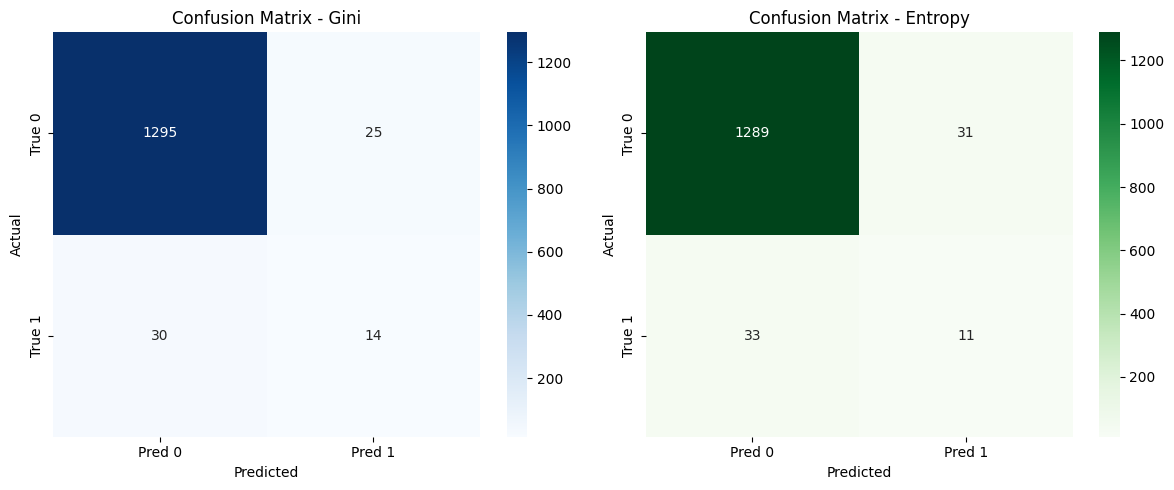

In [33]:
# Tampilkan Confusion Matrix untuk model Gini dan Entropy dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.

from sklearn.metrics import confusion_matrix

cm_gini = confusion_matrix(y_test, y_pred_gini)
cm_entropy = confusion_matrix(y_test, y_pred_entropy)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_gini, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
axes[0].set_title('Confusion Matrix - Gini')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_entropy, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
axes[1].set_title('Confusion Matrix - Entropy')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

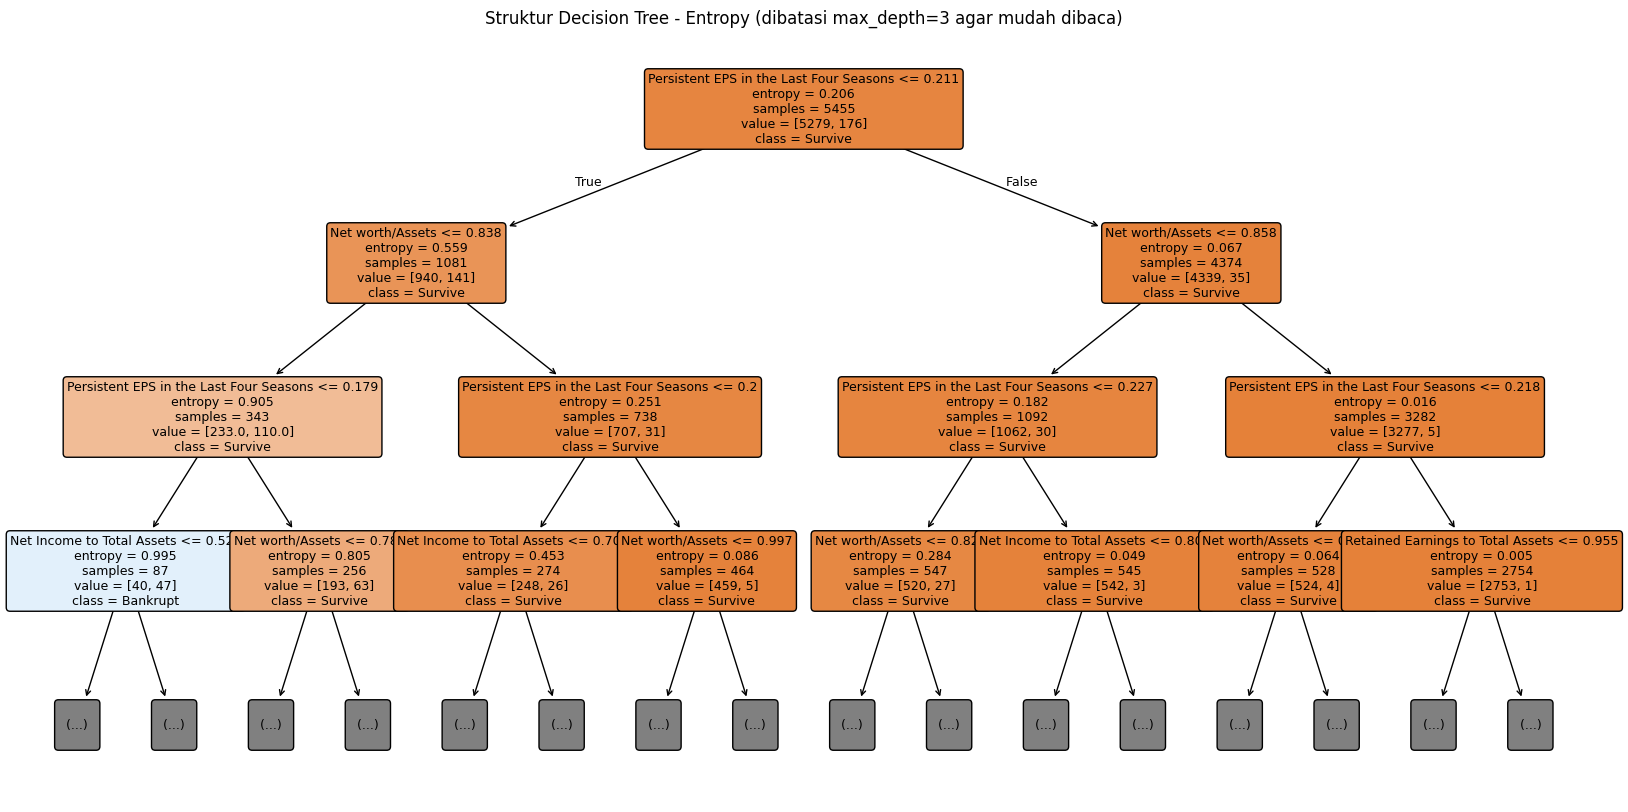

In [34]:
# Visualisasikan struktur Decision Tree (gunakan plot_tree) untuk model dengan performa terbaik.
# Batasi kedalaman visualisasi (misalnya max_depth=2 atau 3 pada parameter plot_tree) agar tetap mudah dibaca.

from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(clf_entropy, max_depth=3,
          feature_names=list(X.columns),
          class_names=['Survive', 'Bankrupt'],
          filled=True, rounded=True, fontsize=9)
plt.title('Struktur Decision Tree - Entropy (dibatasi max_depth=3 agar mudah dibaca)')
plt.show()

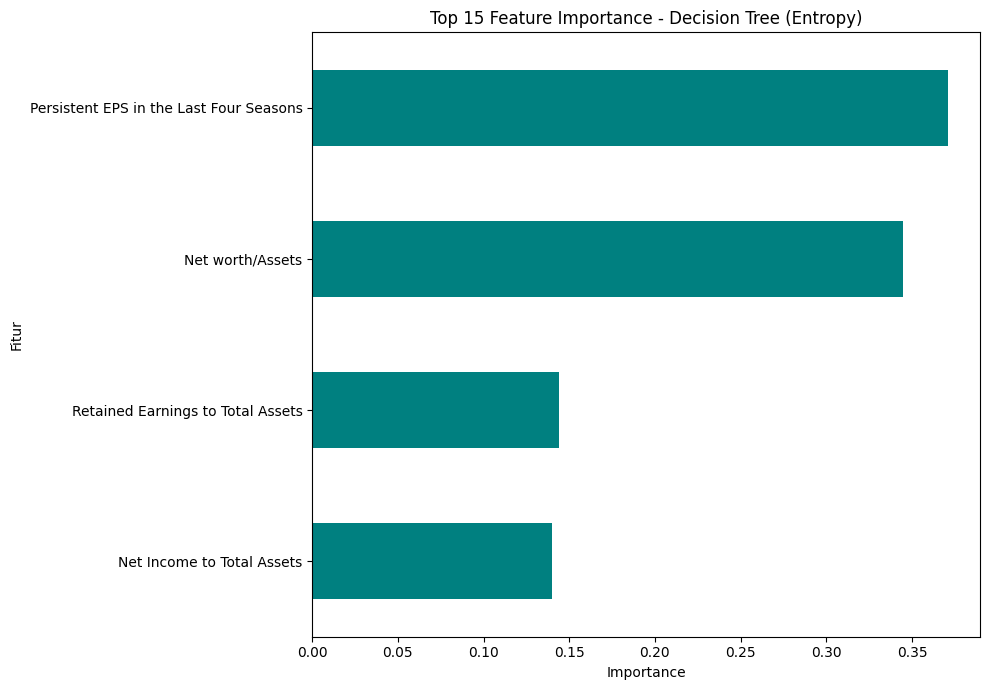

Persistent EPS in the Last Four Seasons    0.3711
Net worth/Assets                           0.3449
Retained Earnings to Total Assets          0.1443
Net Income to Total Assets                 0.1397
dtype: float64

In [35]:
# Tampilkan feature importance dari model terbaik dalam bentuk bar chart horizontal.
# Urutkan dari fitur yang paling berpengaruh.

importances = pd.Series(clf_entropy.feature_importances_, index=X.columns).sort_values()
top_n = importances.tail(15)  # 15 fitur terpenting, sudah terurut ascending untuk barh

plt.figure(figsize=(10, 7))
top_n.plot(kind='barh', color='teal')
plt.title('Top 15 Feature Importance - Decision Tree (Entropy)')
plt.xlabel('Importance')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()
display(importances.sort_values(ascending=False).head(15).round(4))

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

1. Perbandingan Kriteria Split (Gini Impurity vs Entropy)
Pengujian menggunakan kriteria Gini Impurity dan Entropy menghasilkan performa yang relatif identik, dengan tingkat akurasi pada data testing berada di kisaran 95% hingga 96%. Hal ini terjadi karena secara matematis kedua kriteria tersebut memiliki karakteristik kurva ketidakmurnian (impurity) yang sangat serupa, sehingga batas pemisahan (split boundary) yang dipilih pada setiap node umumnya sama. Selain itu, faktor utama yang mempengaruhi performa model dalam dataset ini lebih didominasi oleh struktur ketidakseimbangan kelas (imbalanced dataset) ketimbang pemilihan fungsi kriteria split.

2. Evaluasi Regularisasi (max_depth) dan Gejala Overfitting
Pengaturan kedalaman pohon (max_depth) terbukti berpengaruh signifikan terhadap tingkat generalisasi model:

Kondisi Optimal: Model mencapai performa terbaik pada kisaran max_depth 3 sampai 4. Pada kedalaman ini, akurasi data training dan data testing berada pada nilai yang seimbang dengan jarak (gap) yang sangat tipis.

Gejala Overfitting: Indikasi overfitting mulai terlihat ketika max_depth bernilai 5 atau lebih, dan menjadi sangat jelas saat kedalaman pohon tidak dibatasi (default). Pada kondisi ini, akurasi data training terus meningkat hingga menyentuh angka 100% karena model menghafal seluruh sampel training, sementara akurasi data testing justru melandai atau menurun. Pelebaran jarak antara kurva training dan testing pada grafik menunjukkan bahwa model kehilangan kemampuan generalisasi untuk data baru.

3. Fitur Paling Berpengaruh (Feature Importance)
Berdasarkan nilai feature importance yang dihasilkan oleh model Decision Tree, terdapat tiga indikator keuangan utama yang paling dominan dalam memprediksi risiko kebangkrutan perusahaan:

Net Income to Total Assets (ROA): Merupakan indikator efisiensi perusahaan dalam menghasilkan laba bersih relatif terhadap total aset yang dimiliki.

Persistent EPS in the Last Four Seasons / Net Value Per Share: Mengukur tingkat konsistensi pendapatan dan kekuatan nilai ekuitas bersih perusahaan dari waktu ke waktu.

Debt Ratio %: Indikator tingkat leverage atau proporsi utang perusahaan yang menjadi faktor pemicu utama kegagalan finansial.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Penggunaan kriteria Gini maupun Entropy memberikan hasil yang hampir sama. Untuk menghindari masalah overfitting dan mempertahankan kemudahan interpretasi model, penggunaan max_depth dibatasi pada nilai 3 atau 4 adalah pilihan yang paling ideal. Untuk pengembangan eksperimen berikutnya, disarankan menerapkan teknik penanganan ketidakseimbangan kelas (seperti SMOTE atau undersampling) agar model dapat lebih sensitif dalam mendeteksi perusahaan yang berisiko bangkrut.